# Floor vs no-floor: which configurations sample at all, and what they cost

**Read this before the charts.** Every floor run at C10 and above has an acceptance rate of
**0.000** with **100% divergences on all 8 chains**. Those runs are not slow — they are not
sampling. Each iteration takes one leapfrog step, the ODE solve fails, the proposal is rejected,
and the position never moves. Cost-per-step for such a run is not a measurement of anything, so
**every dead checkpoint is removed from the timing series outright** — not
merely flagged — so a run with no live checkpoints contributes no points at all rather than a
fabricated cost curve.

That makes the C8→C10 "cliff" a working/not-working boundary rather than a scaling effect: any
power-law fit to the floor condition past C8 would be fitting a line through three live points and
a plateau of dead ones, not a real trend.

Two charts, each for **warmup**, **sampling**, and the two concatenated (**all**):

1. **Cost scaling** — median throughput against reaction count, log–log, fitted over live runs only.
2. **Per-system detail** — one panel per system, two lines each.

Throughput is **windowed**: steps between checkpoints ÷ the compute seconds that window took.

In the `all` view sampling draws are offset past `n_tune` and put back on the run's own clock, so
the phases form one series; a dotted vertical line marks the handover.

**Compute seconds, not wall clock.** These run on the preemptable QOS, so a raw delta between log
entries can span a queue wait. `export_progress_series.py` resolves each entry against its `sacct`
intervals (`--duplicates`) first, and also carries each run's `health` block from `draws.zarr`.

In [1]:
# Run the exporter on the cluster; pulls back tens of KB of (step -> seconds).
import subprocess, json, pathlib

REMOTE = "/projects/anth4580/Bayesian/job_files/export_progress_series.py"
REMOTE_PY = "/projects/anth4580/software/anaconda/envs/Bayesian/bin/python"

# Analysis scripts run on an Alpine interactive (acompile) node, never the login node:
# these walk every checkpoint and recompute r-hat/ESS, which is real work and does not
# belong on a shared login node. SLURM_CONF has to be set explicitly -- loading the slurm
# module alone leaves it pointing at whichever cluster the login node belongs to.
SRUN = ("export SLURM_CONF=/curc/slurm/alpine/etc/slurm.conf; "
        "srun --partition=acompile --qos=compile --account=ucb634_asc2 "
        "--nodes=1 --ntasks=1 --cpus-per-task=4 --time=00:40:00 ")

LOCAL = pathlib.Path("series.json")

# One string, not ["bash","-lc",cmd]: ssh re-joins argv with spaces, so -lc would
# take only the first word. The script self-adds its dir to sys.path, so no cd.
proc = subprocess.run(["ssh", "curc", SRUN + f"{REMOTE_PY} {REMOTE}"],
                      stdout=subprocess.PIPE, stderr=subprocess.PIPE)
if proc.returncode != 0:
    raise RuntimeError(proc.stderr.decode()[-2000:])

LOCAL.write_bytes(proc.stdout)
DATA = json.loads(proc.stdout)
print(f"{LOCAL} <- {len(proc.stdout)/1024:.1f} KB")
for setname, systems in DATA.items():
    n_samp = sum(1 for v in systems.values() if v["sampling"])
    print(f"  {setname:<20} {len(systems):>2} systems  ({n_samp} into sampling)")

series.json <- 1059.0 KB
  tightest             14 systems  (3 into sampling)
  tightest_nofloor     14 systems  (14 into sampling)
  narrowest_matched     2 systems  (1 into sampling)
  narrowest_nofloor     4 systems  (4 into sampling)
  a1c2_no_floor         3 systems  (0 into sampling)
  a1c3_no_floor         3 systems  (3 into sampling)
  a1c3a2_no_floor       3 systems  (2 into sampling)
  a1c3d1_no_floor       3 systems  (0 into sampling)


In [2]:
import re
from contextlib import contextmanager
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# (label, floor set key, no-floor set key)
COMPARISONS = [
    ("a1 [0.1, 10]",   "tightest",          "tightest_nofloor"),
    ("a1 [0.05, 20]",  "narrowest_matched", "narrowest_nofloor"),
]
SPLIT = 10        #  Short/long chain split
MIN_POINTS = 3    # below this a line of best fit says nothing
WINDOW_STEPS = 5 # rate is measured over intervals at least this many steps wide, min=5
LOG_RATE = False
LOG_SPEEDUP = False
PALETTE = "tab20"   # any matplotlib colormap name: Set2, tab10, hsv, turbo, viridis, ...

MATCH_INDEX = True   # cut both conditions at the highest index BOTH reached before
                     # taking medians. Once every run has converged this is a no-op
                     # for warmup (all reach 1000), but NOT for sampling: runs stop
                     # at whatever draw they converged on, so the endpoints still
                     # differ. Set False to use each run's own full phase.
MAX_COMPUTE_HOURS = None  # global default: no cap. The "why is the floor slow"
                          # section scopes a cap locally with compute_cap(8.0);
                          # everywhere else uses each run's full history.

NORMALIZE_HW = True   # rescale every interval to A100-equivalent wall clock
REF_DEVICE = "NVIDIA A100-PCIE-40GB"
# Device factors, cross-checked by three independent routes. The problem they
# solve: a live run's throughput rises ~2.2x over warmup on its own, so a device
# switch that coincides with a stage change looks like a hardware effect.
#
#   (a) dead-run cost law. Dead runs sit at max_steps every iteration, so their
#       rate depends only on (system size, device) -- no stage effect at all.
#       Fitting the six A100 dead runs gives rate ∝ rxns^-1.16 with R²=0.988,
#       tight enough to predict what any system WOULD cost on an A100 and read a
#       device's factor off its residual. This reaches cards that never shared a
#       run with an A100.
#   (b) direct within-run overlap on a dead run (only C14 qualifies).
#   (c) live runs with a shared binned stage curve removed and divergent windows
#       excluded: log(rate) = run + g(step) + device, model R²=0.790 against
#       0.408 with no stage term.
#
#                    (a) dead law   (b) overlap   (c) stage-corrected   adopted
#   H100 NVL            1.38 (n=4)     1.36            --                1.37
#   H100 MIG 3g.40gb    0.88 (n=2)     --              0.93              0.90
#   V100-SXM2-32GB      --             --              0.67              0.67
#   V100-PCIE-32GB      --             --              0.75              0.75
#   V100-PCIE-16GB      --             --              0.75              0.75
#
# NVL and MIG agree across methods, so they are solid. The three V100 entries
# rest on (c) alone -- one method, no dead-run corroboration -- so they are the
# weak link; treat any conclusion leaning on a V100-heavy system with care.
DEVICE_FACTORS = {
    "NVIDIA A100-PCIE-40GB":        1.00,   # reference
    "NVIDIA H100 NVL":              1.37,   # (a) 1.38 over 4 systems, (b) 1.36
    "NVIDIA H100 PCIe MIG 3g.40gb": 0.90,   # (a) 0.88, (c) 0.93
    "Tesla V100-SXM2-32GB":         0.67,   # (c) only
    "Tesla V100-PCIE-32GB":         0.75,   # (c) only
    "Tesla V100-PCIE-16GB":         0.75,   # (c) only
}
UNVALIDATED_DEVICES = set()   # every device present now has an estimate

PHASES = ["warmup", "sampling", "all"]

# Reactions after template expansion (build_ode_system_from_reactions).
# C4_NoFB is the C4 YAML set minus FabF/FabB -- a different model, hence 56 not 82.
N_REACTIONS = {
    "C4_NoFB": 56, "C6": 121, "C8": 160, "C10": 199, "C12": 238,
    "C12+unsat": 274, "C14": 277, "C14+unsat": 352, "C16": 316,
    "C16+unsat": 430, "C18": 355, "C18+unsat": 508, "C20": 394,
    "C20+unsat": 586,
}

def chain_len(name):
    m = re.match(r"C(\d+)", name)
    return int(m.group(1)) if m else 999

def chain_key(name):
    """Ascending chain length, saturated before +unsat at the same length."""
    return (chain_len(name), "+unsat" in name, name)

def n_tune_of(setkey, system):
    return DATA.get(setkey, {}).get(system, {}).get("n_tune", 1000) or 1000

def device_map(setkey, system, phase):
    """{checkpoint index: device that wrote it}."""
    rec = DATA.get(setkey, {}).get(system, {})
    dw = {int(k): v for k, v in (rec.get("device_warmup") or {}).items()}
    ds = {int(k): v for k, v in (rec.get("device_sampling") or {}).items()}
    if phase == "warmup":
        return dw
    if phase == "sampling":
        return ds
    nt = n_tune_of(setkey, system)
    out = dict(dw); out.update({nt + d: v for d, v in ds.items()})
    return out


def devices_used(setkey, system):
    rec = DATA.get(setkey, {}).get(system, {})
    return set((rec.get("device_warmup") or {}).values()) | \
           set((rec.get("device_sampling") or {}).values())


def was_adjusted(setkey, system):
    """True when any part of this run was measured off the reference GPU, so its
    timings are either rescaled (validated card) or partly dropped (unvalidated)."""
    return NORMALIZE_HW and bool(devices_used(setkey, system) - {REF_DEVICE})


def star(setkey, system):
    return "*" if was_adjusted(setkey, system) else ""


def _to_reference(series, devmap):
    """Cumulative seconds as if every interval ran on REF_DEVICE.

    Applied per interval, not per run: a run can migrate between cards at a job
    boundary and several here did, so scaling a total by one factor would smear
    the wrong correction across segments already on the reference.

    Checkpoints written on a device with no validated factor are dropped rather
    than guessed at, and the interval that spans the gap goes with them.
    """
    ks = sorted(series)
    out, acc, prev = {}, 0.0, None
    for k in ks:
        dev = devmap.get(k)
        if dev in UNVALIDATED_DEVICES:
            prev = None            # break the chain; next interval starts fresh
            continue
        f = DEVICE_FACTORS.get(dev, 1.0)
        if prev is not None:
            acc += (series[k] - series[prev]) * f
        else:
            acc += series[k] * f if not out else 0.0
        out[k] = acc
        prev = k
    return out


@contextmanager
def compute_cap(hours):
    """Apply an equal-compute cap to everything inside the block, then restore.

    Scoped rather than global because the cap answers one specific question --
    what each condition achieves per unit of compute -- and would silently
    truncate the cost-scaling and startup figures, which want each run's whole
    history.
    """
    global MAX_COMPUTE_HOURS
    prev = MAX_COMPUTE_HOURS
    MAX_COMPUTE_HOURS = hours
    try:
        yield
    finally:
        MAX_COMPUTE_HOURS = prev


def dead_set(setkey, system, phase):
    """Checkpoint indices whose block had every chain at zero acceptance.

    Per-checkpoint, not per-run: a block where nothing was accepted contributes
    a seconds-per-step that measures the cost of failing. Averaging that in with
    live blocks would understate throughput for a run that is mostly working,
    and for a run that never worked it manufactures a cost curve out of nothing.
    """
    rec = DATA.get(setkey, {}).get(system, {})
    dw = set(rec.get("dead_warmup") or [])
    ds = set(rec.get("dead_sampling") or [])
    if phase == "warmup":
        return dw
    if phase == "sampling":
        return ds
    nt = n_tune_of(setkey, system)
    return dw | {nt + d for d in ds}


def phase_series(setkey, system, phase, drop_dead=True):
    """{index: cumulative_compute_seconds}. Index is warmup step, sampling draw,
    or for "all" a single axis with sampling offset past n_tune.

    Dead checkpoints are removed by default, so nothing downstream can average
    a failing block into a rate.
    """
    rec = DATA.get(setkey, {}).get(system, {})
    warm = {int(k): v for k, v in rec.get("warmup", {}).items()}
    samp = {int(k): v for k, v in rec.get("sampling", {}).items()}
    def _finish(d):
        if drop_dead:
            d = {k: v for k, v in d.items() if k not in dead_set(setkey, system, phase)}
        if NORMALIZE_HW:
            d = _to_reference(d, device_map(setkey, system, phase))
        if MAX_COMPUTE_HOURS:
            cap = MAX_COMPUTE_HOURS * 3600.0
            d = {k: v for k, v in d.items() if v <= cap}
        return d

    if phase == "warmup":
        return _finish(warm)
    if phase == "sampling":
        return _finish(samp)
    nt = n_tune_of(setkey, system)
    end_t = warm.get(nt)
    if end_t is None:          # warmup unfinished: nothing to concatenate onto
        return dict(warm)
    out = dict(warm)
    out.update({nt + d: end_t + t for d, t in samp.items()})
    return _finish(out)

def block_stat(setkey, system, phase, what):
    """{checkpoint index: value} for solves / stepsize / accept."""
    key = {"warmup": f"{what}_warmup", "sampling": f"{what}_sampling"}.get(phase)
    rec = DATA.get(setkey, {}).get(system, {})
    if phase == "all":
        w = {int(k): v for k, v in (rec.get(f"{what}_warmup") or {}).items()}
        nt = n_tune_of(setkey, system)
        w.update({nt + int(k): v for k, v in (rec.get(f"{what}_sampling") or {}).items()})
        return w
    return {int(k): v for k, v in (rec.get(key) or {}).items()}


def cost_per_solve(setkey, system, phase, width=None, cap=None):
    """(x, seconds per ODE solve) -- wall time divided by integrator steps.

    A sampler iteration can contain 1 or 100+ leapfrog steps, each needing its
    own ODE solve, so steps-per-second cannot separate "took more steps" from
    "each step was expensive". This can: it is the cost of one unit of work.

    cap, when given, drops checkpoints past that index -- for a stranded-chain
    system whose live run kept sampling well past its real (retroactively
    corrected) convergence point, so the tail doesn't inflate the picture.
    """
    sd = phase_series(setkey, system, phase)
    if cap is not None:
        sd = {k: v for k, v in sd.items() if k <= cap}
    solves = block_stat(setkey, system, phase, "solves")
    xs, ys = [], []
    for a, b in step_windows(sorted(sd), width, dead_set(setkey, system, phase)):
        n = sum(v for k, v in solves.items() if a < k <= b)
        dt = sd[b] - sd[a]
        if n > 0 and dt > 0:
            xs.append((a + b) / 2); ys.append(dt / n)
    return np.array(xs), np.array(ys)


def step_windows(ks, width=None, dead=frozenset()):
    """Non-overlapping (start, end) pairs at least `width` steps apart.

    Checkpoints land every 5 steps, fine enough that one slow step dominates its
    interval. Wider windows average that out but cost resolution -- hence the knob.

    A window is discarded if a dead checkpoint falls inside it. Dead checkpoints
    are already absent from the series, so without this the window would silently
    bridge the gap and charge the failing blocks' seconds to the live steps on
    either side.
    """
    width = WINDOW_STEPS if width is None else width
    out, a = [], None
    for k in ks:
        if a is None:
            a = k
        elif k - a >= width:
            if not any(a < d <= k for d in dead):
                out.append((a, k))
            a = k
    return out

def rate_curve(setkey, system, phase, width=None):
    """(x, steps_per_second) per window; x is the window midpoint.

    Empty when every checkpoint in the phase was dead -- that run contributes
    no cost data at all, which is the honest outcome.
    """
    s = phase_series(setkey, system, phase)
    xs, ys = [], []
    for a, b in step_windows(sorted(s), width, dead_set(setkey, system, phase)):
        dn, dt = b - a, s[b] - s[a]
        if dn > 0 and dt > 0:
            xs.append((a + b) / 2); ys.append(dn / dt)
    return np.array(xs), np.array(ys)

def _r2(obs, pred):
    ss_tot = float(np.sum((obs - obs.mean()) ** 2))
    return 1.0 - float(np.sum((obs - pred) ** 2)) / ss_tot if ss_tot > 0 else float("nan")

def fit_rate(x, y, log=None):
    """(label, r_squared, predict) for a throughput trend, matched to the axis.

    Fitted in whatever space the panel is drawn in, so the line is straight on
    screen and R^2 describes what the eye sees.
    """
    log = LOG_RATE if log is None else log
    if log:
        ly = np.log10(y)
        a, b = np.polyfit(x, ly, 1)
        return ("\u00d7%.2f/100st" % 10 ** (100 * a), _r2(ly, a * x + b),
                lambda gx: 10 ** (a * gx + b))
    a, b = np.polyfit(x, y, 1)
    return ("%+.4f/100st" % (100 * a), _r2(y, a * x + b), lambda gx: a * gx + b)

def health(setkey, system):
    return DATA.get(setkey, {}).get(system, {}).get("health") or {}

def is_dead(setkey, system):
    """True when no chain is accepting: the run is producing no draws at all.

    Kept separate from "slow". A run at 100% divergence has a well-defined
    seconds-per-step, but that number measures the cost of failing, so letting
    it into a cost fit silently turns a broken configuration into a data point.
    """
    h = health(setkey, system)
    if not h or not h.get("n_chains"):
        return False
    return h.get("dead_chains", 0) >= h["n_chains"]

def health_note(setkey, system):
    h = health(setkey, system)
    if not h:
        return ""
    if is_dead(setkey, system):
        return f"DEAD accept={h['acceptance']:.3f} div={100*h['divergence']:.0f}%"
    return f"accept={h['acceptance']:.3f} div={100*h['divergence']:.0f}%"


def systems_in(fset, nset):
    return sorted(set(DATA.get(fset, {})) | set(DATA.get(nset, {})), key=chain_key)

ALL_SYSTEMS = sorted({s for st in DATA.values() for s in st}, key=chain_key)

def _system_colors(palette=None):
    """One colour per system, shared by every panel and every phase."""
    cm = plt.get_cmap(palette or PALETTE)
    qualitative = getattr(cm, "colors", None) is not None
    if qualitative and cm.N < len(ALL_SYSTEMS):
        print(f"note: {PALETTE!r} has {cm.N} colours for {len(ALL_SYSTEMS)} systems "
              f"-- {len(ALL_SYSTEMS) - cm.N} will repeat. "
              f"Use tab20, or a continuous map (turbo, viridis, hsv).")
    n = max(len(ALL_SYSTEMS) - 1, 1)
    return {sys_: (cm(i % cm.N) if qualitative else cm(i / n))
            for i, sys_ in enumerate(ALL_SYSTEMS)}

COLOR = _system_colors()
# Change palette without re-fetching:  COLOR = _system_colors("turbo")

print(f"rate window: {WINDOW_STEPS} steps\n")
print(f"{'PRIOR':<11}{'SYSTEM':<12}{'FLOOR':<34}{'NO-FLOOR':<34}")
print("-" * 91)
for label, fset, nset in COMPARISONS:
    short = label.split()[0]
    for s in systems_in(fset, nset):
        print(f"{short:<11}{s:<12}{health_note(fset, s):<34}{health_note(nset, s):<34}")
print("-" * 91)
print("DEAD = every chain at zero acceptance. Such checkpoints are REMOVED from every")
print("series below, so a run with no live checkpoints contributes no points at all.")
print()
print(f"{'PRIOR':<11}{'SYSTEM':<12}{'COND':<9}{'checkpoints':>12}{'dead':>6}{'kept':>6}")
print("-" * 56)
if NORMALIZE_HW:
    adj = [(lbl.split()[0], s, sorted(devices_used(k, s) - {REF_DEVICE}))
           for lbl, f, n in COMPARISONS for k in (f, n)
           for s in systems_in(f, n) if was_adjusted(k, s)]
    print()
    print(f"HARDWARE NORMALISATION: {len(adj)} run(s) rescaled to "
          f"{REF_DEVICE}-equivalent wall clock (marked * in the plots)")
    for short, s, devs in adj:
        print(f"  {short:<11}{s:<12}" +
              ", ".join(f"{d.replace('NVIDIA ','').replace('Tesla ','')}"
                        f" x{DEVICE_FACTORS.get(d, 1.0):.2f}" for d in devs))
for label, fset, nset in COMPARISONS:
    short = label.split()[0]
    for s in systems_in(fset, nset):
        for setk, cond in ((fset, "floor"), (nset, "nofloor")):
            rec = DATA.get(setk, {}).get(s, {})
            tot = len(rec.get("warmup", {})) + len(rec.get("sampling", {}))
            d = len(rec.get("dead_warmup") or []) + len(rec.get("dead_sampling") or [])
            if tot:
                print(f"{short:<11}{s:<12}{cond:<9}{tot:>12}{d:>6}{tot-d:>6}")
print("-" * 56)


rate window: 5 steps

PRIOR      SYSTEM      FLOOR                             NO-FLOOR                          
-------------------------------------------------------------------------------------------
a1         C4_NoFB     accept=0.791 div=4%               accept=0.791 div=4%               
a1         C6          accept=0.791 div=4%               accept=0.791 div=2%               
a1         C8          accept=0.791 div=3%               accept=0.791 div=1%               
a1         C10         DEAD accept=0.000 div=100%        accept=0.791 div=3%               
a1         C12         DEAD accept=0.000 div=100%        accept=0.791 div=2%               
a1         C12+unsat   DEAD accept=0.000 div=100%        accept=0.791 div=1%               
a1         C14         DEAD accept=0.000 div=100%        accept=0.791 div=2%               
a1         C14+unsat   DEAD accept=0.000 div=100%        accept=0.791 div=2%               
a1         C16         DEAD accept=0.000 div=100%        a

## Cost scaling with system size

The decision this comparison exists to settle is not "which is faster on C8" but **how cost grows
with the model** — one number per condition.

Reaction counts come from `build_ode_system_from_reactions` after template expansion, so they are
the real solved system rather than a YAML line count.

Each system's two points are taken over the **same index range** — the highest point both
conditions reached — because early warmup steps cost far more than late ones, and a floor run that
stalled at step 30 would otherwise be compared against a no-floor run averaged over 1000.


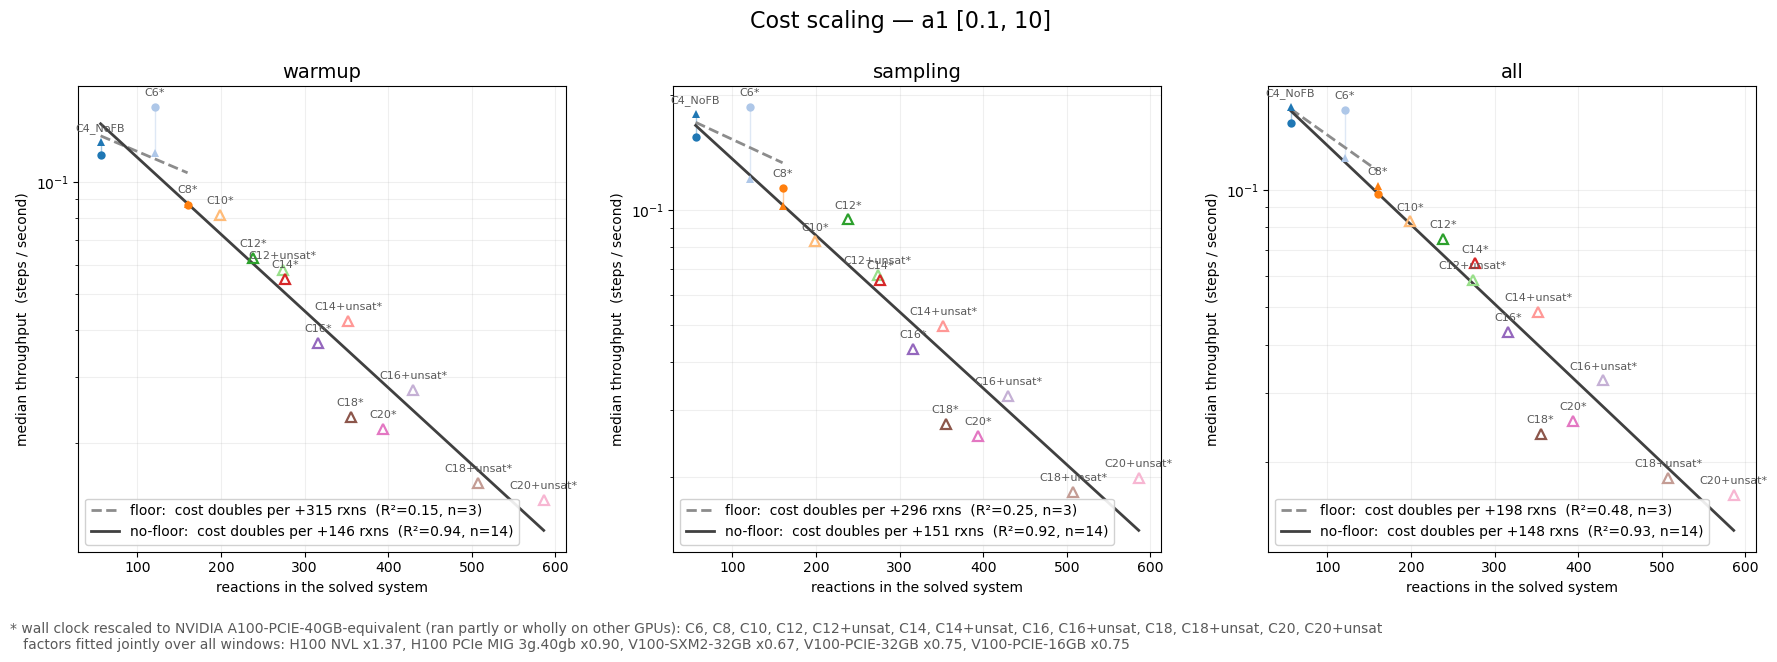

,system,reactions,range,floor_per_s,nofloor_per_s,ratio,n_floor,n_nofloor,pairing
0,C4_NoFB,56,998,0.118231,0.127975,1.082416,199,199,paired
1,C6,121,998,0.159003,0.119617,0.752297,199,199,paired
2,C8*,160,998,0.086851,0.087382,1.006117,199,199,paired
3,C10*,199,998,NaN,0.081873,NaN,0,199,no-floor only
4,C12*,238,998,NaN,0.062696,NaN,0,199,no-floor only
5,C12+unsat*,274,998,NaN,0.058072,NaN,0,199,no-floor only
6,C14,277,998,NaN,0.055084,NaN,0,199,no-floor only
7,C14+unsat*,352,998,NaN,0.042394,NaN,0,199,no-floor only
8,C16*,316,998,NaN,0.036984,NaN,0,199,no-floor only
9,C16+unsat*,430,998,NaN,0.027664,NaN,0,199,no-floor only


,system,reactions,range,floor_per_s,nofloor_per_s,ratio,n_floor,n_nofloor,pairing
0,C4_NoFB,56,698,0.154895,0.177936,1.148754,139,139,paired
1,C6,121,398,0.185742,0.120337,0.647870,79,79,paired
2,C8*,160,398,0.114286,0.102712,0.898726,79,79,paired
3,C10*,199,498,NaN,0.082836,NaN,0,99,no-floor only
4,C12*,238,398,NaN,0.094530,NaN,0,79,no-floor only
5,C12+unsat*,274,498,NaN,0.067613,NaN,0,99,no-floor only
6,C14,277,398,NaN,0.065755,NaN,0,79,no-floor only
7,C14+unsat*,352,398,NaN,0.049845,NaN,0,79,no-floor only
8,C16*,316,398,NaN,0.043309,NaN,0,79,no-floor only
9,C16+unsat*,430,398,NaN,0.032673,NaN,0,79,no-floor only


,system,reactions,range,floor_per_s,nofloor_per_s,ratio,n_floor,n_nofloor,pairing
0,C4_NoFB,56,1698,0.148368,0.162602,1.095935,339,339,paired
1,C6,121,1398,0.159688,0.120279,0.753211,279,279,paired
2,C8*,160,1398,0.097504,0.102333,1.049529,279,279,paired
3,C10*,199,1498,NaN,0.082809,NaN,0,299,no-floor only
4,C12*,238,1398,NaN,0.074627,NaN,0,279,no-floor only
5,C12+unsat*,274,1498,NaN,0.058713,NaN,0,299,no-floor only
6,C14,277,1398,NaN,0.064599,NaN,0,279,no-floor only
7,C14+unsat*,352,1398,NaN,0.048515,NaN,0,279,no-floor only
8,C16*,316,1398,NaN,0.043129,NaN,0,279,no-floor only
9,C16+unsat*,430,1398,NaN,0.032360,NaN,0,279,no-floor only


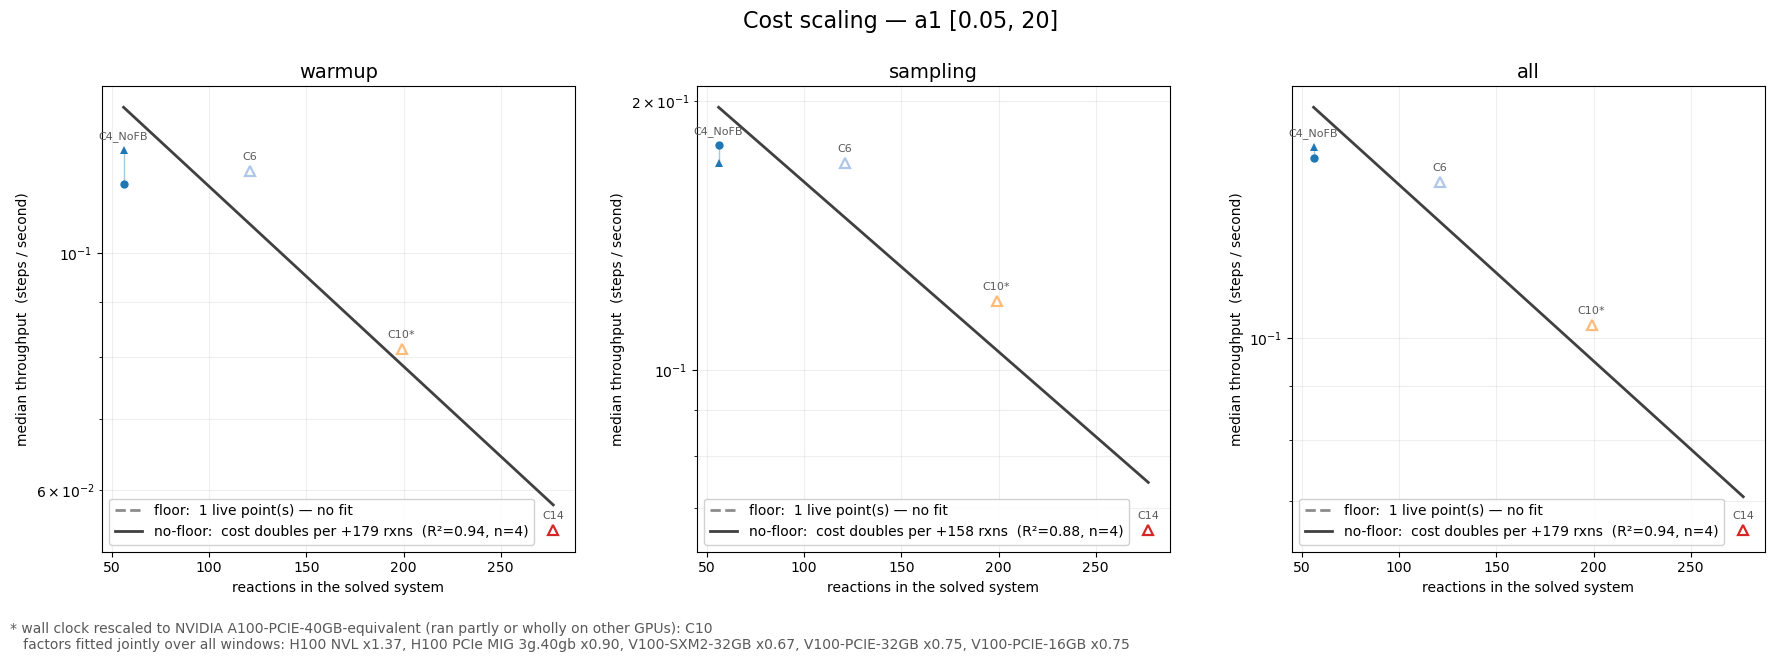

,system,reactions,range,floor_per_s,nofloor_per_s,ratio,n_floor,n_nofloor,pairing
0,C4_NoFB,56,998,0.116009,0.124906,1.076692,199,199,paired
1,C6,121,998,NaN,0.119332,NaN,0,199,no-floor only
2,C10*,199,998,NaN,0.081274,NaN,0,199,no-floor only
3,C14,277,998,NaN,0.054999,NaN,0,199,no-floor only


,system,reactions,range,floor_per_s,nofloor_per_s,ratio,n_floor,n_nofloor,pairing
0,C4_NoFB,56,602,0.178412,0.170126,0.953557,120,120,paired
1,C6,121,398,NaN,0.170474,NaN,0,79,no-floor only
2,C10*,199,1202,NaN,0.119397,NaN,0,240,no-floor only
3,C14,277,498,NaN,0.066076,NaN,0,99,no-floor only


,system,reactions,range,floor_per_s,nofloor_per_s,ratio,n_floor,n_nofloor,pairing
0,C4_NoFB,56,1602,0.148655,0.152045,1.022807,320,320,paired
1,C6,121,1398,NaN,0.140845,NaN,0,279,no-floor only
2,C10*,199,2202,NaN,0.102909,NaN,0,440,no-floor only
3,C14,277,1498,NaN,0.065634,NaN,0,299,no-floor only


In [3]:
def hw_note(fig, fset, nset, systems):
    """Footnote naming the runs whose timings were rescaled."""
    if not NORMALIZE_HW:
        return
    adj = sorted({s for s in systems for k in (fset, nset) if was_adjusted(k, s)},
                 key=chain_key)
    if not adj:
        return
    fig.text(0.005, -0.02,
             "* wall clock rescaled to " + REF_DEVICE + "-equivalent (ran partly or "
             "wholly on other GPUs): " + ", ".join(adj)
             + "\n   factors fitted jointly over all windows: "
             + ", ".join(f"{d.replace('NVIDIA ','').replace('Tesla ','')} x{v:.2f}"
                         for d, v in DEVICE_FACTORS.items() if d != REF_DEVICE),
             fontsize=10, color="0.35", va="top", ha="left")


def condition_medians(fset, nset, system, phase, curve_fn=rate_curve):
    """(floor_med, nofloor_med, hi, n_f, n_n, paired) -- either may be None.

    curve_fn defaults to rate_curve (steps/second); the cost-per-solve panel
    below passes cost_per_solve instead, reusing the same pairing/index-
    matching logic rather than duplicating it for a second metric."""
    fx, fy = curve_fn(fset, system, phase)
    nx, ny = curve_fn(nset, system, phase)
    have_f, have_n = len(fx) > 0, len(nx) > 0
    if not (have_f or have_n):
        return None
    if have_f and have_n:
        hi = min(fx.max(), nx.max()) if MATCH_INDEX else max(fx.max(), nx.max())
        fm, nm = (fy[fx <= hi], ny[nx <= hi]) if MATCH_INDEX else (fy, ny)
        if not len(fm) or not len(nm):
            return None
        return float(np.median(fm)), float(np.median(nm)), hi, len(fm), len(nm), True
    hi = fx.max() if have_f else nx.max()
    return (float(np.median(fy)) if have_f else None,
            float(np.median(ny)) if have_n else None,
            hi, len(fx), len(nx), False)


def scaling_panel(ax, label, fset, nset, phase):
    pts = []
    for s in systems_in(fset, nset):
        if s not in N_REACTIONS:
            continue
        m = condition_medians(fset, nset, s, phase)
        if m:
            pts.append((s, N_REACTIONS[s]) + m)
    if not pts:
        ax.text(.5, .5, f"no live data in {phase} yet", ha="center", va="center",
                transform=ax.transAxes, color="0.45")
        ax.set_title(phase, fontsize=14)
        return []

    for idx, cond, style, grey in ((2, "floor", "--", "0.55"),
                                   (3, "no-floor", "-", "0.25")):
        live = [(p[1], p[idx]) for p in pts if p[idx]]
        if len(live) >= 3:
            lx = np.array([p[0] for p in live], float)
            ly = np.array([p[1] for p in live], float)
            a, b = np.polyfit(lx, np.log10(ly), 1)
            r2 = _r2(np.log10(ly), a * lx + b)
            dbl = np.log10(0.5) / a
            gx = np.linspace(lx.min(), lx.max(), 50)
            ax.plot(gx, 10 ** (a * gx + b), style, lw=2, color=grey,
                    label=f"{cond}:  cost doubles per +{dbl:.0f} rxns  "
                          f"(R\u00b2={r2:.2f}, n={len(live)})")
        elif live:
            ax.plot([], [], style, lw=2, color=grey,
                    label=f"{cond}:  {len(live)} live point(s) \u2014 no fit")

    for s, r, fm, nm, hi, nf, nn, paired in pts:
        if fm and nm:
            ax.plot([r, r], [fm, nm], "-", lw=1.0, color=COLOR[s], alpha=.4, zorder=0)
        for val, mk in ((fm, "o"), (nm, "^")):
            if not val:
                continue
            if paired:
                ax.plot([r], [val], mk, ms=6, mew=0, color=COLOR[s])
            else:
                ax.plot([r], [val], mk, ms=7, mfc="none", mew=1.6, color=COLOR[s])
        lbl = s + ("*" if (was_adjusted(fset, s) or was_adjusted(nset, s)) else "")
        ax.annotate(lbl, (r, max(v for v in (fm, nm) if v)),
                    textcoords="offset points", xytext=(0, 8), ha="center",
                    fontsize=8, color="0.35")

    ax.set_yscale("log")
    ax.set_xlabel("reactions in the solved system")
    ax.set_ylabel("median throughput  (steps / second)")
    ax.set_title(phase, fontsize=14)
    ax.grid(alpha=.2, which="both")
    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=10, loc="lower left", framealpha=.9)
    return pts


for label, fset, nset in COMPARISONS:
    fig, axes = plt.subplots(1, len(PHASES), figsize=(6.0 * len(PHASES), 6.0))
    tables = {}
    for ax, ph in zip(axes, PHASES):
        tables[ph] = scaling_panel(ax, label, fset, nset, ph)
    fig.suptitle(f"Cost scaling — {label}", fontsize=16, y=1.0)
    hw_note(fig, fset, nset, systems_in(fset, nset))
    plt.tight_layout(); plt.show()

    for ph in PHASES:
        pts = tables[ph]
        if not pts:
            continue
        df_scaling = pd.DataFrame([
            {
                "system": s + star(nset if nm else fset, s),
                "reactions": r,
                "range": f"{hi:.0f}",
                "floor_per_s": fm,
                "nofloor_per_s": nm,
                "ratio": nm / fm if fm and nm else None,
                "n_floor": nf,
                "n_nofloor": nn,
                "pairing": "paired" if paired else ("no-floor only" if nm else "floor only"),
            }
            for s, r, fm, nm, hi, nf, nn, paired in pts
        ])
        display(df_scaling)

### Same trend, in the unit that actually costs compute: seconds per ODE solve

Steps/second above answers "is the sampler moving fast"; this answers "what does
one unit of work cost" -- the same distinction the per-system cost-per-solve
traces in the section below make over time, just collapsed to one median point
per system so it can be compared against reaction count directly, same layout as
the throughput panels above (warmup / sampling / all, floor vs. no-floor, log10-
linear fit gated on `MIN_POINTS`). Cost rises with system size here rather than
falling, so the fit is reported as a doubling distance in the other direction.

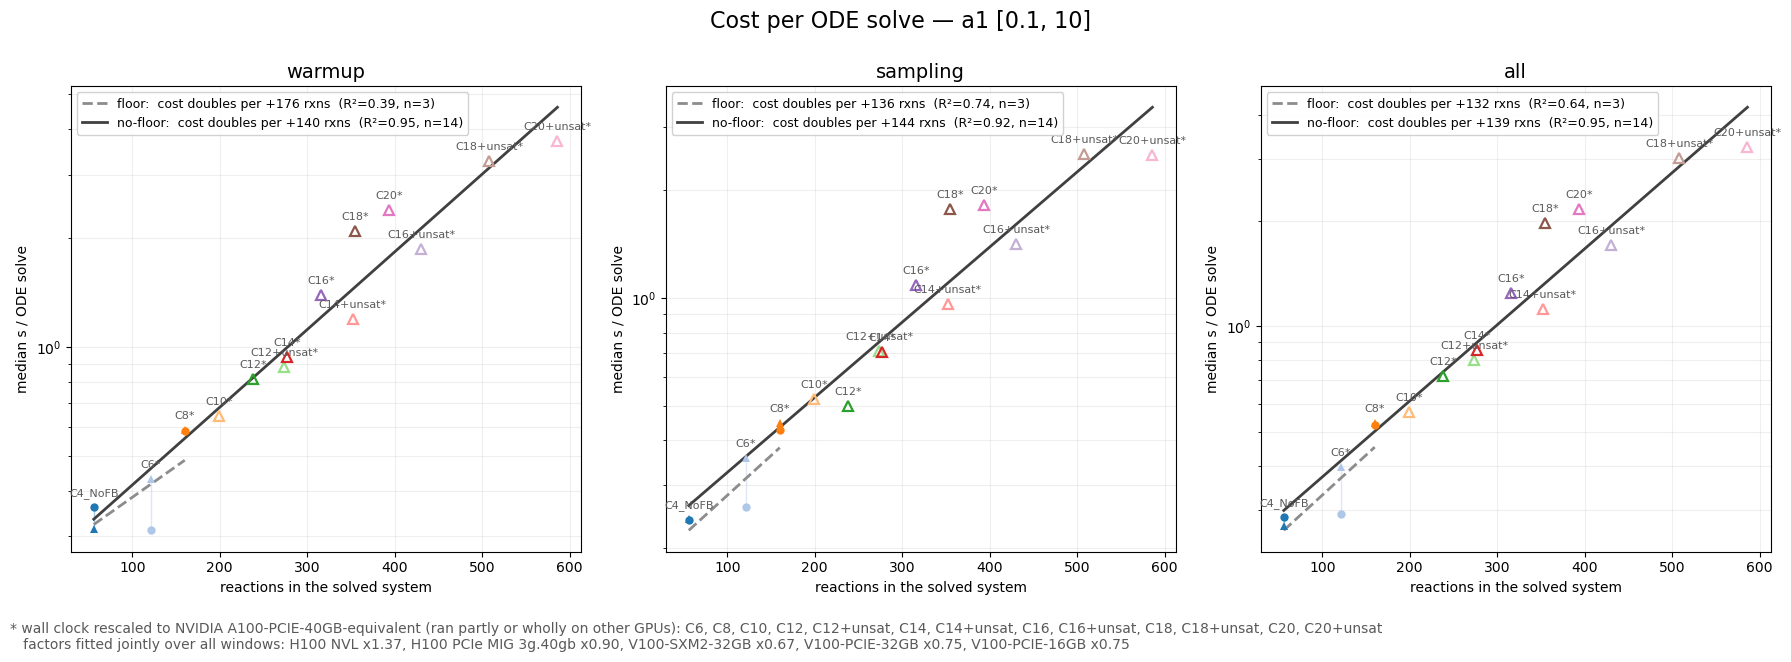

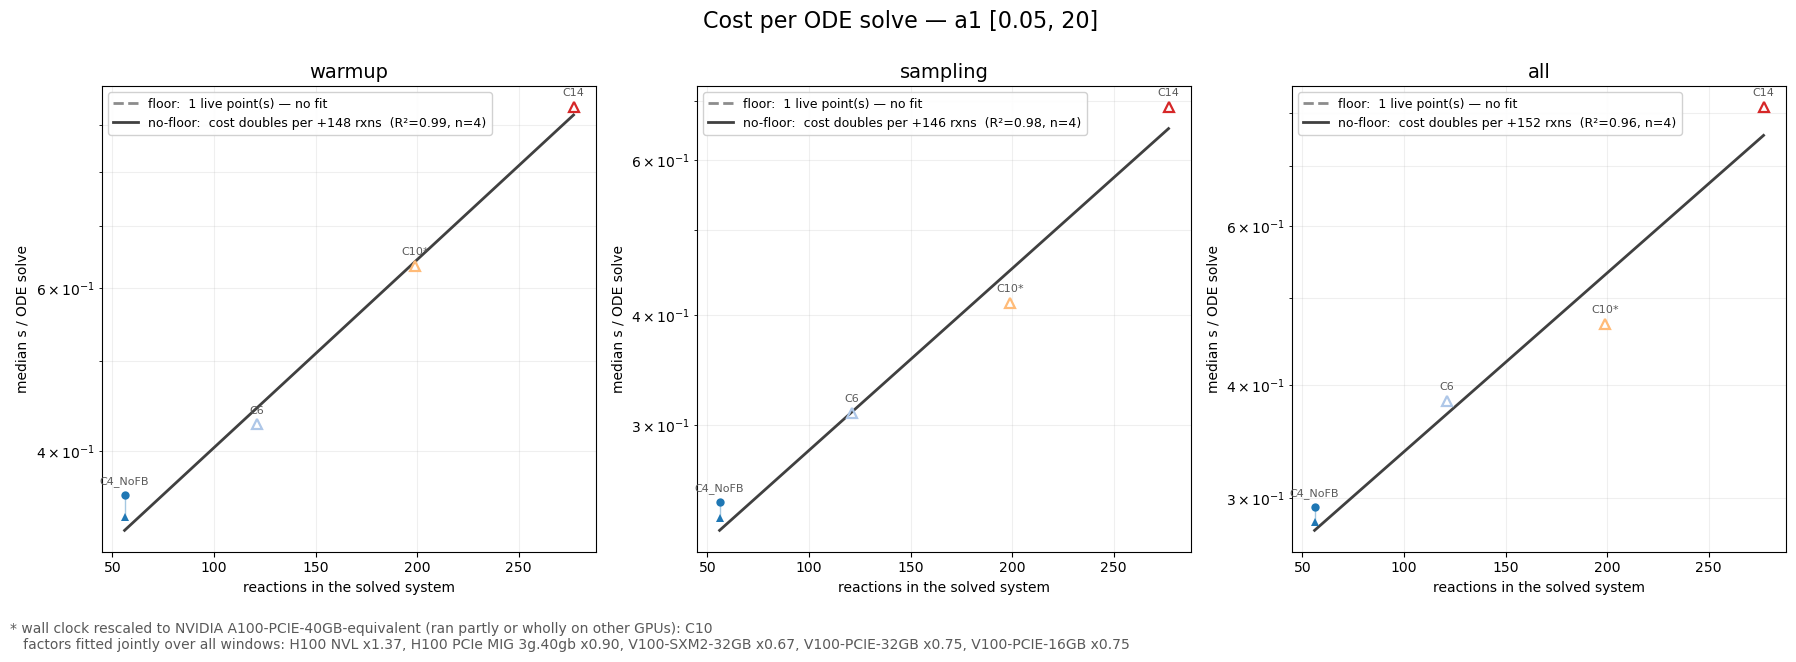

In [4]:
def solve_cost_panel(ax, label, fset, nset, phase):
    """condition_medians(..., curve_fn=cost_per_solve), plotted exactly like
    scaling_panel() above -- same pairing, marker, and annotation conventions --
    but for median seconds/ODE-solve instead of median steps/second. Cost
    increases with reactions rather than decreasing, so the doubling distance
    is log10(2)/a, not log10(0.5)/a.
    """
    pts = []
    for s in systems_in(fset, nset):
        if s not in N_REACTIONS:
            continue
        m = condition_medians(fset, nset, s, phase, curve_fn=cost_per_solve)
        if m:
            pts.append((s, N_REACTIONS[s]) + m)
    if not pts:
        ax.text(.5, .5, f"no live data in {phase} yet", ha="center", va="center",
                transform=ax.transAxes, color="0.45")
        ax.set_title(phase, fontsize=14)
        return []

    for idx, cond, style, grey in ((2, "floor", "--", "0.55"),
                                   (3, "no-floor", "-", "0.25")):
        live = [(p[1], p[idx]) for p in pts if p[idx]]
        if len(live) >= MIN_POINTS:
            lx = np.array([p[0] for p in live], float)
            ly = np.array([p[1] for p in live], float)
            a, b = np.polyfit(lx, np.log10(ly), 1)
            r2 = _r2(np.log10(ly), a * lx + b)
            gx = np.linspace(lx.min(), lx.max(), 50)
            if a > 0:
                trend = f"cost doubles per +{np.log10(2) / a:.0f} rxns"
            elif a < 0:
                trend = f"cost halves per +{-np.log10(2) / a:.0f} rxns"
            else:
                trend = "flat"
            ax.plot(gx, 10 ** (a * gx + b), style, lw=2, color=grey,
                    label=f"{cond}:  {trend}  (R\u00b2={r2:.2f}, n={len(live)})")
        elif live:
            ax.plot([], [], style, lw=2, color=grey,
                    label=f"{cond}:  {len(live)} live point(s) \u2014 no fit")

    for s, r, fm, nm, hi, nf, nn, paired in pts:
        if fm and nm:
            ax.plot([r, r], [fm, nm], "-", lw=1.0, color=COLOR[s], alpha=.4, zorder=0)
        for val, mk in ((fm, "o"), (nm, "^")):
            if not val:
                continue
            if paired:
                ax.plot([r], [val], mk, ms=6, mew=0, color=COLOR[s])
            else:
                ax.plot([r], [val], mk, ms=7, mfc="none", mew=1.6, color=COLOR[s])
        lbl = s + ("*" if (was_adjusted(fset, s) or was_adjusted(nset, s)) else "")
        ax.annotate(lbl, (r, max(v for v in (fm, nm) if v)),
                    textcoords="offset points", xytext=(0, 8), ha="center",
                    fontsize=8, color="0.35")

    ax.set_yscale("log")
    ax.set_xlabel("reactions in the solved system")
    ax.set_ylabel("median s / ODE solve")
    ax.set_title(phase, fontsize=14)
    ax.grid(alpha=.2, which="both")
    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=9, loc="upper left", framealpha=.9)
    return pts


for label, fset, nset in COMPARISONS:
    fig, axes = plt.subplots(1, len(PHASES), figsize=(6.0 * len(PHASES), 6.0))
    for ax, ph in zip(axes, PHASES):
        solve_cost_panel(ax, label, fset, nset, ph)
    fig.suptitle(f"Cost per ODE solve — {label}", fontsize=16, y=1.0)
    hw_note(fig, fset, nset, systems_in(fset, nset))
    plt.tight_layout(); plt.show()

## Startup cost

Every throughput number above starts at the **W5 checkpoint**, so none of them include what the run
spent getting there: XLA compilation, the 100k-draw prior sample, and the first 5 warmup steps.
Those three can't be separated — the first log entry is written at `warmup_done=5` — so this is
their sum, and it is the one cost the rate charts deliberately exclude.

It is worth its own chart because for the long chains it stops being a rounding error: the right
panel shows it as a share of all compute a run has done so far.


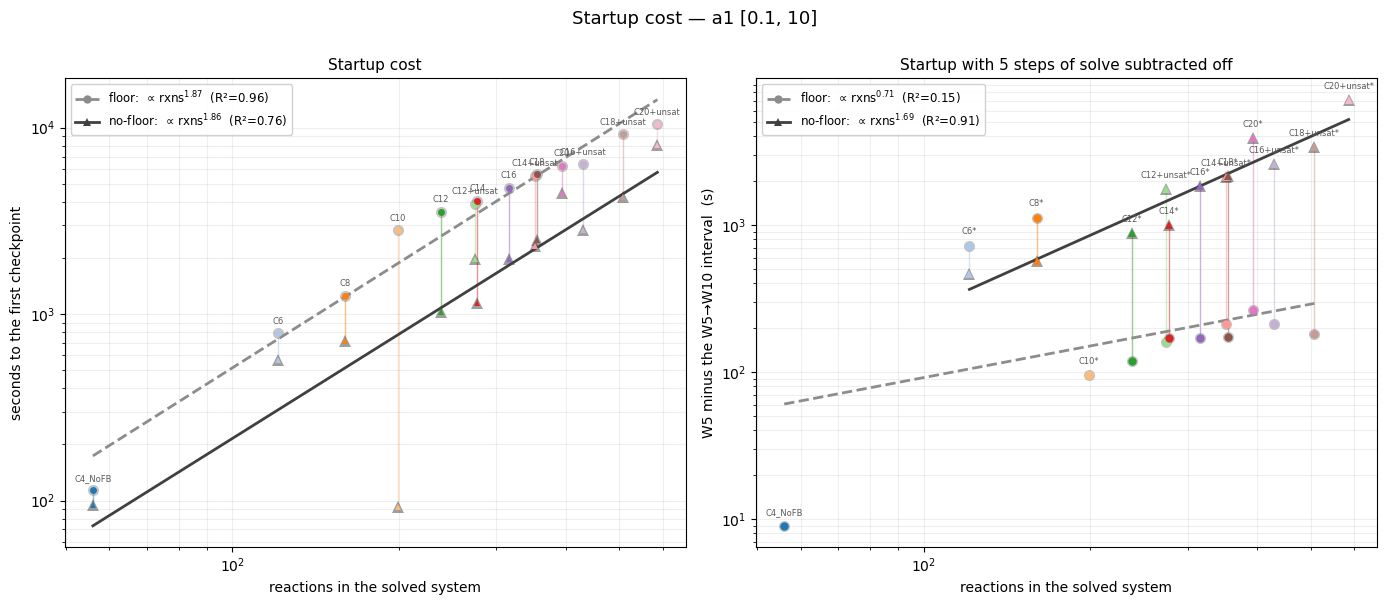

a1 [0.1, 10]
SYSTEM        RXNS      FLOOR    NOFLOOR   ratio  fl %tot  nf %tot   fl corr   nf corr
---------------------------------------------------------------------------------------
C4_NoFB         56    0:01:53    0:01:34    1.21       1%       1%   0:00:08  -0:00:01
C6             121    0:13:08    0:09:26    1.39       6%       2%   0:12:03   0:07:44
C8             160    0:20:57    0:11:55    1.76       5%       3%   0:18:42   0:09:31
C10            199    0:46:56    0:01:32   30.44       3%       0%   0:01:35  -0:00:32
C12            238    0:58:41    0:17:09    3.42      13%       4%   0:01:59   0:14:38
C12+unsat      274    1:05:18    0:32:44    2.00      15%       7%   0:02:40   0:29:18
C14            277    1:07:41    0:19:09    3.53      11%       3%   0:02:50   0:16:35
C14+unsat      352    1:31:49    0:38:26    2.39      16%       7%   0:03:30   0:35:15
C16            316    1:18:56    0:32:45    2.41      11%       5%   0:02:51   0:30:30
C16+unsat      430    1:45:58

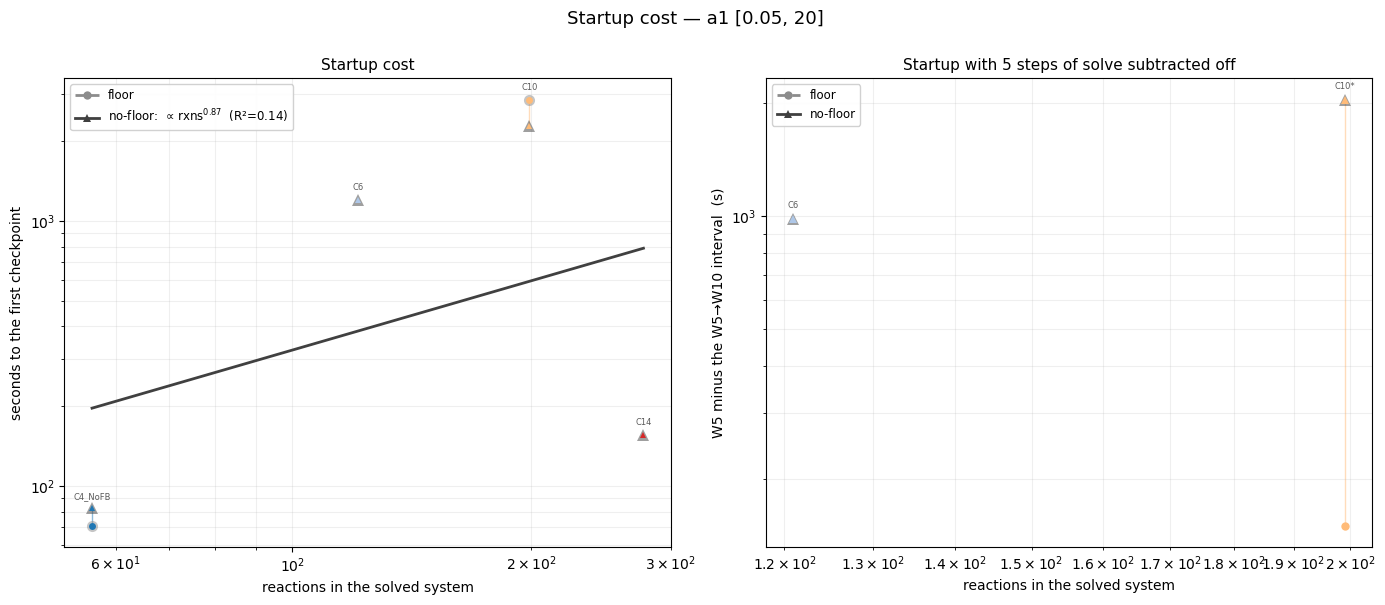

a1 [0.05, 20]
SYSTEM        RXNS      FLOOR    NOFLOOR   ratio  fl %tot  nf %tot   fl corr   nf corr
---------------------------------------------------------------------------------------
C4_NoFB         56    0:01:10    0:01:22    0.86       1%       1%  -0:00:53  -0:00:40
C6             121          -    0:19:59       -        -       6%         -   0:16:24
C10            199    0:47:42    0:38:03    1.25      10%       7%   0:02:29   0:34:06
C14            277          -    0:02:35       -        -       0%         -  -0:00:36


In [5]:
def _warm(setkey, system):
    """Hardware-normalised warmup series, dead checkpoints KEPT.

    Startup is paid whether or not the sampler goes on to accept anything, so
    unlike the cost panels this one must not drop dead runs -- they are most of
    the floor ladder. It does still need the device correction, which reading
    DATA["warmup"] directly would skip.
    """
    return phase_series(setkey, system, "warmup", drop_dead=False)


def startup_cost(setkey, system):
    """Compute seconds to the first checkpoint: JIT + prior sample + first 5 steps."""
    return _warm(setkey, system).get(5)


def startup_corrected(setkey, system):
    """W5 minus the W5->W10 interval, as an attempt to strip the 5 solved steps.

    Uses the next 5 steps as a stand-in for the first 5, which is the only
    estimate available -- and it is a poor one in both directions. Early NUTS
    iterations have shallow trees, so steps 5-10 often cost MORE than steps 1-5
    and the subtraction overshoots (some corrected values go negative). Under
    no-floor the opposite happens: the first steps sit at the worst parameter
    values, so they cost more than 5-10 and the subtraction leaves solve time
    behind. Read it as a bound, not a measurement.
    """
    w = _warm(setkey, system)
    a, b = w.get(5), w.get(10)
    if a is None or b is None:
        return None
    return a - (b - a)


def total_compute(setkey, system):
    w = _warm(setkey, system)
    return max(w.values()) if w else None


def hms(x):
    if x is None:
        return "-"
    neg, x = x < 0, int(abs(x))
    return ("-" if neg else "") + f"{x//3600}:{(x%3600)//60:02d}:{x%60:02d}"


for label, fset, nset in COMPARISONS:
    rows = []
    for s in systems_in(fset, nset):
        if s not in N_REACTIONS:
            continue
        f, n = startup_cost(fset, s), startup_cost(nset, s)
        if f or n:
            rows.append((s, N_REACTIONS[s], f, n,
                         total_compute(fset, s), total_compute(nset, s),
                         startup_corrected(fset, s), startup_corrected(nset, s)))
    if not rows:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    fitinfo = {}
    for idx, cond, style, marker, grey in ((2, "floor", "--", "o", "0.55"),
                                           (3, "no-floor", "-", "^", "0.25")):
        pts = [(r[1], r[idx]) for r in rows if r[idx]]
        if len(pts) < 2:
            continue
        rx = np.array([p[0] for p in pts], float)
        yv = np.array([p[1] for p in pts], float)
        ax.plot(rx, yv, marker, ms=8, mew=0, ls="none", color=grey, alpha=.5)
        if len(pts) >= 3:
            a, b = np.polyfit(np.log10(rx), np.log10(yv), 1)
            r2 = _r2(np.log10(yv), a * np.log10(rx) + b)
            gx = np.geomspace(rx.min(), rx.max(), 50)
            ax.plot(gx, 10 ** (a * np.log10(gx) + b), style, lw=2, color=grey,
                    label=None)
            fitinfo[cond] = f"\u221d rxns$^{{{a:.2f}}}$  (R\u00b2={r2:.2f})"
    for s, rx, f, n, ft, nt, fc, nc in rows:
        if f and n:
            ax.plot([rx, rx], [f, n], "-", lw=1.0, color=COLOR[s], alpha=.5, zorder=0)
        if f: ax.plot([rx], [f], "o", ms=5, mew=0, color=COLOR[s])
        if n: ax.plot([rx], [n], "^", ms=5, mew=0, color=COLOR[s])
        ax.annotate(s, (rx, max(v for v in (f, n) if v)), textcoords="offset points",
                    xytext=(0, 7), ha="center", fontsize=6, color="0.35")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("reactions in the solved system")
    ax.set_ylabel("seconds to the first checkpoint")
    ax.set_title("Startup cost", fontsize=11)
    ax.grid(alpha=.2, which="both")
    handles = [Line2D([0], [0], color=g, ls=st, lw=2, marker=mk, ms=6, mew=0,
                      label=f"{c}:  {fitinfo[c]}" if c in fitinfo else c)
               for c, st, mk, g in (("floor", "--", "o", "0.55"),
                                    ("no-floor", "-", "^", "0.25"))]
    if handles:
        ax.legend(handles=handles, fontsize=8.5, loc="upper left", framealpha=.9)

    ax = axes[1]
    fitinfo = {}
    for idx, cond, style, marker, grey in ((6, "floor", "--", "o", "0.55"),
                                           (7, "no-floor", "-", "^", "0.25")):
        pts = [(r[1], r[idx]) for r in rows if r[idx] and r[idx] > 0]
        if len(pts) < 2:
            continue
        rx = np.array([p[0] for p in pts], float)
        yv = np.array([p[1] for p in pts], float)
        ax.plot(rx, yv, marker, ms=8, mew=0, ls="none", color=grey, alpha=.5)
        if len(pts) >= 3:
            a, b = np.polyfit(np.log10(rx), np.log10(yv), 1)
            r2 = _r2(np.log10(yv), a * np.log10(rx) + b)
            gx = np.geomspace(rx.min(), rx.max(), 50)
            ax.plot(gx, 10 ** (a * np.log10(gx) + b), style, lw=2, color=grey,
                    label=None)
            fitinfo[cond] = f"\u221d rxns$^{{{a:.2f}}}$  (R\u00b2={r2:.2f})"
    for s, rx, f, n, ft, nt, fc, nc in rows:
        if fc and nc and fc > 0 and nc > 0:
            ax.plot([rx, rx], [fc, nc], "-", lw=1.0, color=COLOR[s], alpha=.5, zorder=0)
        if fc and fc > 0: ax.plot([rx], [fc], "o", ms=6, mew=0, color=COLOR[s])
        if nc and nc > 0: ax.plot([rx], [nc], "^", ms=6, mew=0, color=COLOR[s])
        top = [v for v in (fc, nc) if v and v > 0]
        if top:
            ax.annotate(s + ("*" if (was_adjusted(fset, s) or was_adjusted(nset, s))
                             else ""),
                        (rx, max(top)), textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=6, color="0.35")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("reactions in the solved system")
    ax.set_ylabel("W5 minus the W5\u2192W10 interval  (s)")
    ax.set_title("Startup with 5 steps of solve subtracted off", fontsize=11)
    ax.grid(alpha=.2, which="both")
    handles = [Line2D([0], [0], color=g, ls=st, lw=2, marker=mk, ms=6, mew=0,
                      label=f"{c}:  {fitinfo[c]}" if c in fitinfo else c)
               for c, st, mk, g in (("floor", "--", "o", "0.55"),
                                    ("no-floor", "-", "^", "0.25"))]
    if handles:
        ax.legend(handles=handles, fontsize=8.5, loc="upper left", framealpha=.9)

    fig.suptitle(f"Startup cost — {label}", fontsize=13, y=1.0)
    plt.tight_layout(); plt.show()

    print(f"{label}")
    print(f"{'SYSTEM':<12}{'RXNS':>6}{'FLOOR':>11}{'NOFLOOR':>11}{'ratio':>8}"
          f"{'fl %tot':>9}{'nf %tot':>9}{'fl corr':>10}{'nf corr':>10}")
    print("-" * 87)
    for s, rx, f, n, ft, nt, fc, nc in rows:
        print(f"{s:<12}{rx:>6}{(hms(f) if f else '-'):>11}{(hms(n) if n else '-'):>11}"
              f"{(f'{f/n:.2f}' if f and n else '-'):>8}"
              f"{(f'{100*f/ft:.0f}%' if f and ft else '-'):>9}"
              f"{(f'{100*n/nt:.0f}%' if n and nt else '-'):>9}"
              f"{(hms(fc) if fc is not None else '-'):>10}"
              f"{(hms(nc) if nc is not None else '-'):>10}")

## Per-system detail

One panel per system, ordered by chain length, each showing only its own two conditions. Dots are
measured windows, lines are least-squares fits with R² in the legend. All panels share one pair of axes so they can be read against each
other; the log y scale absorbs the ~200x span across the ladder.

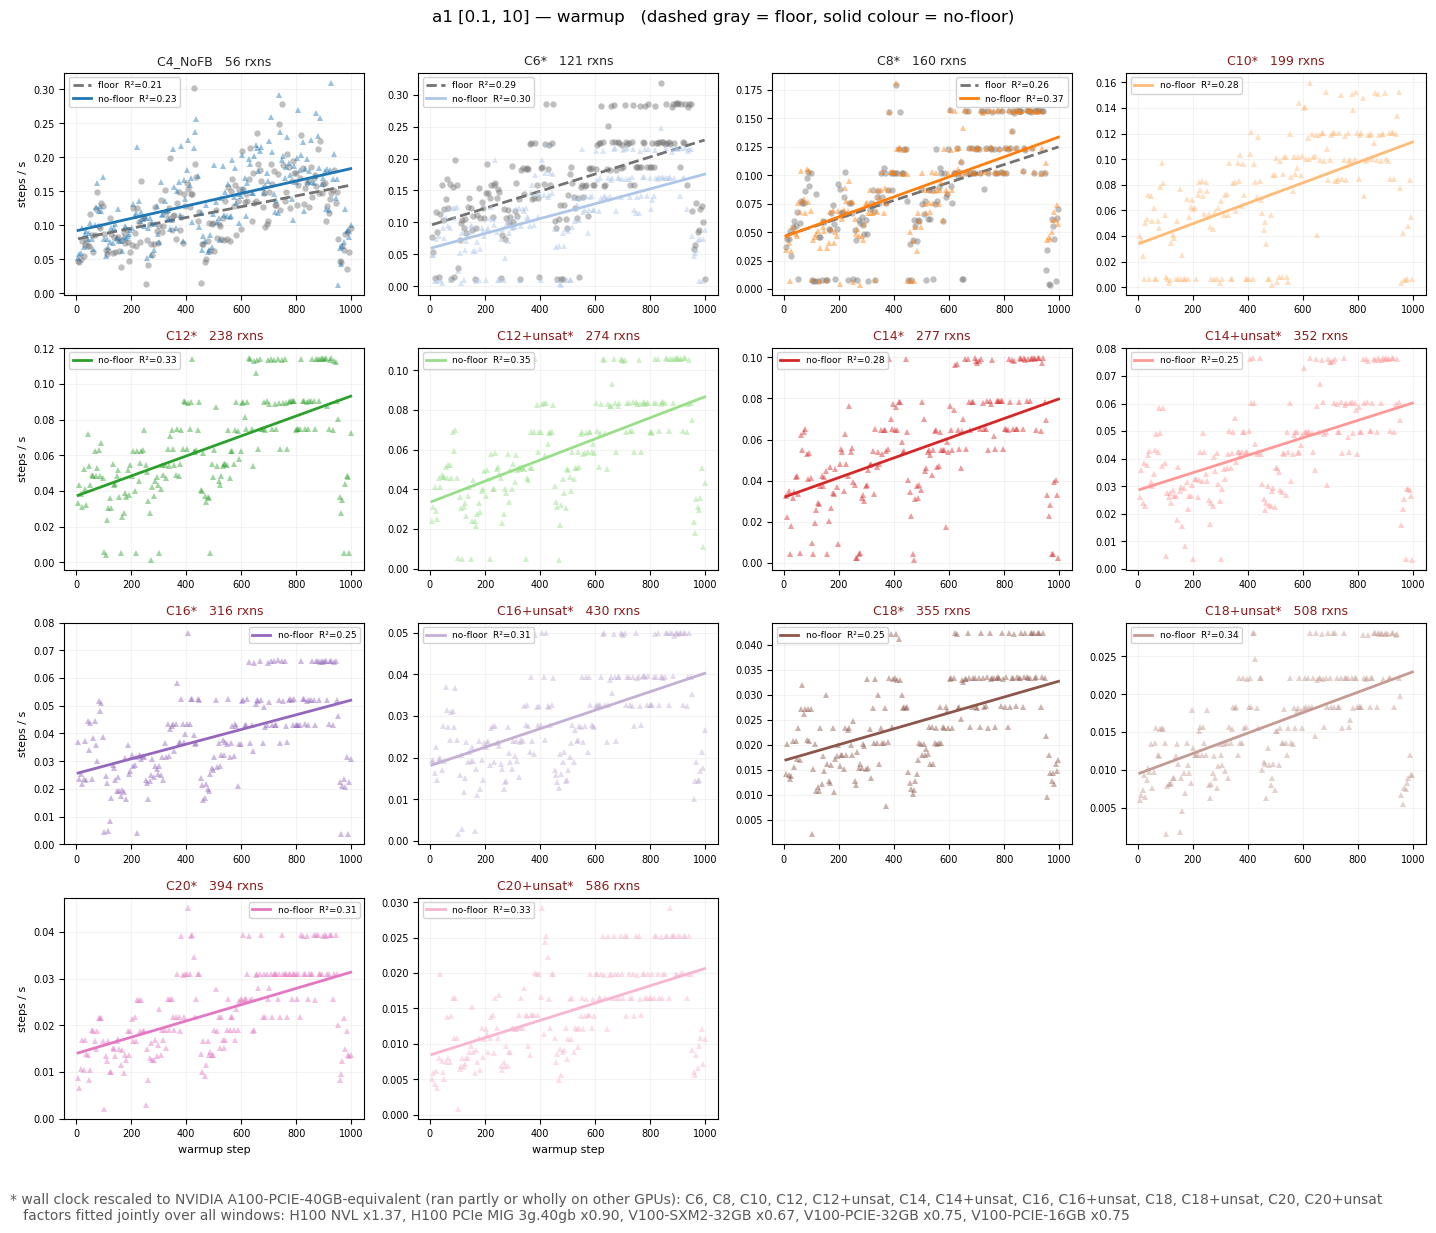

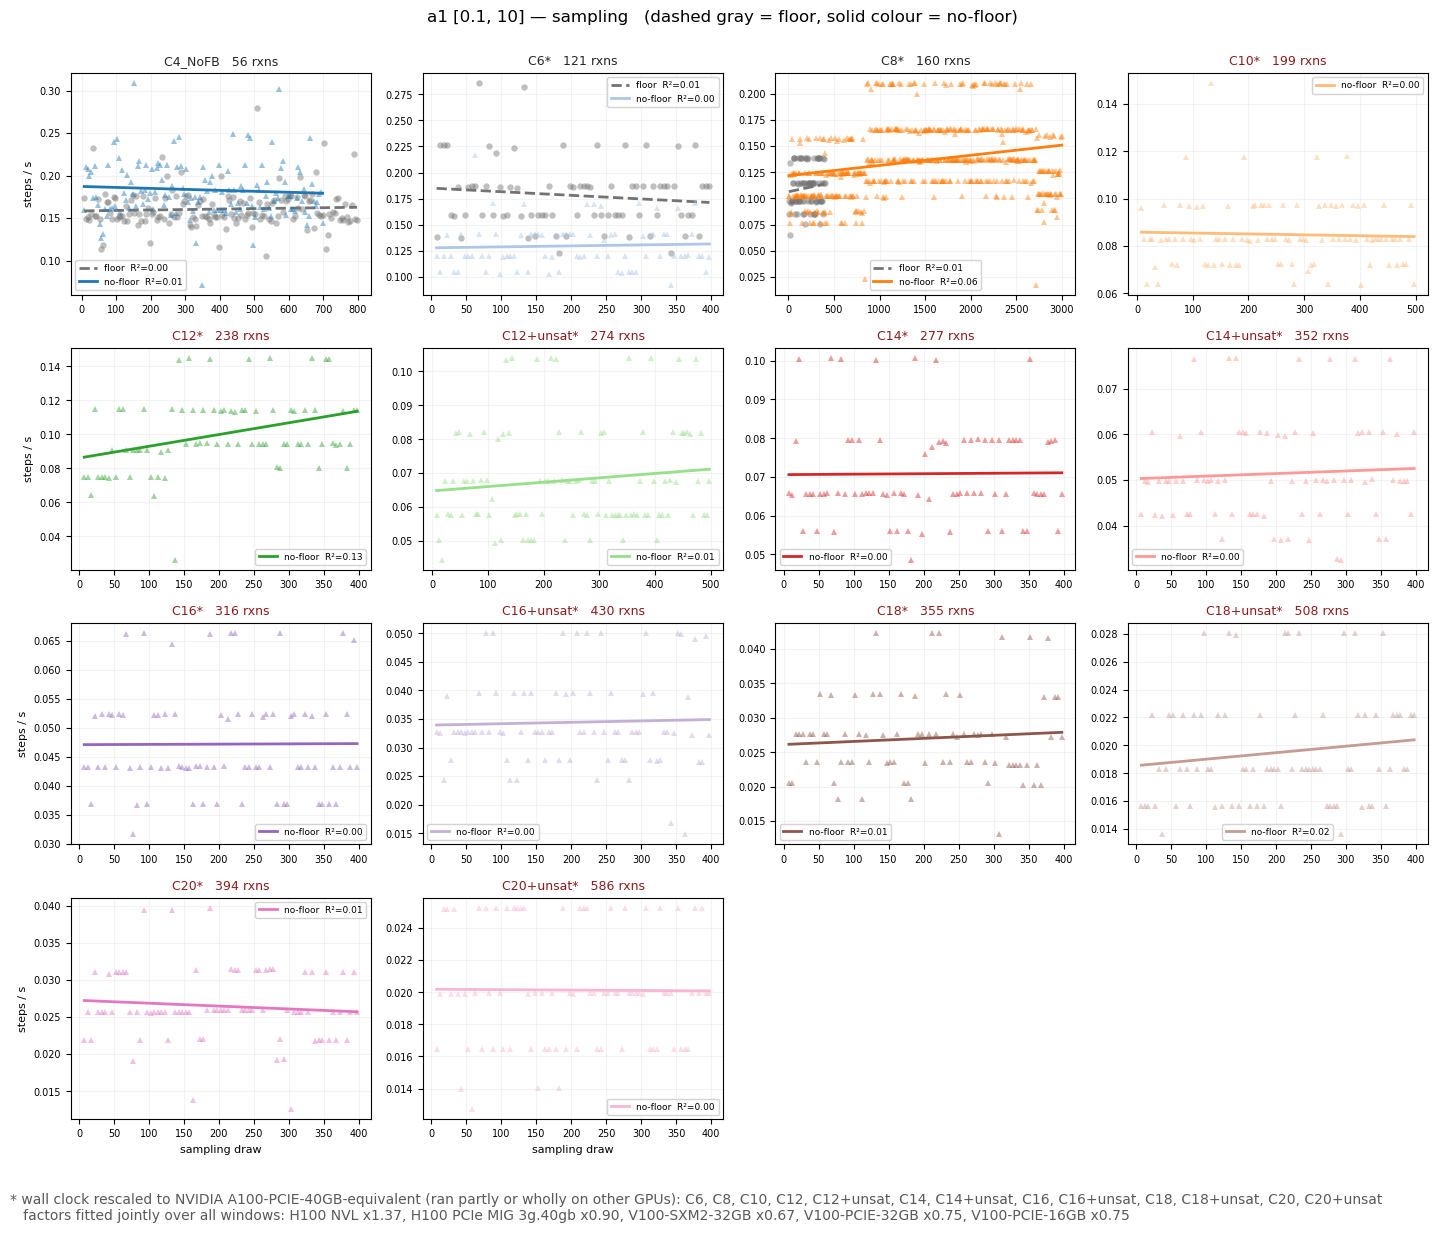

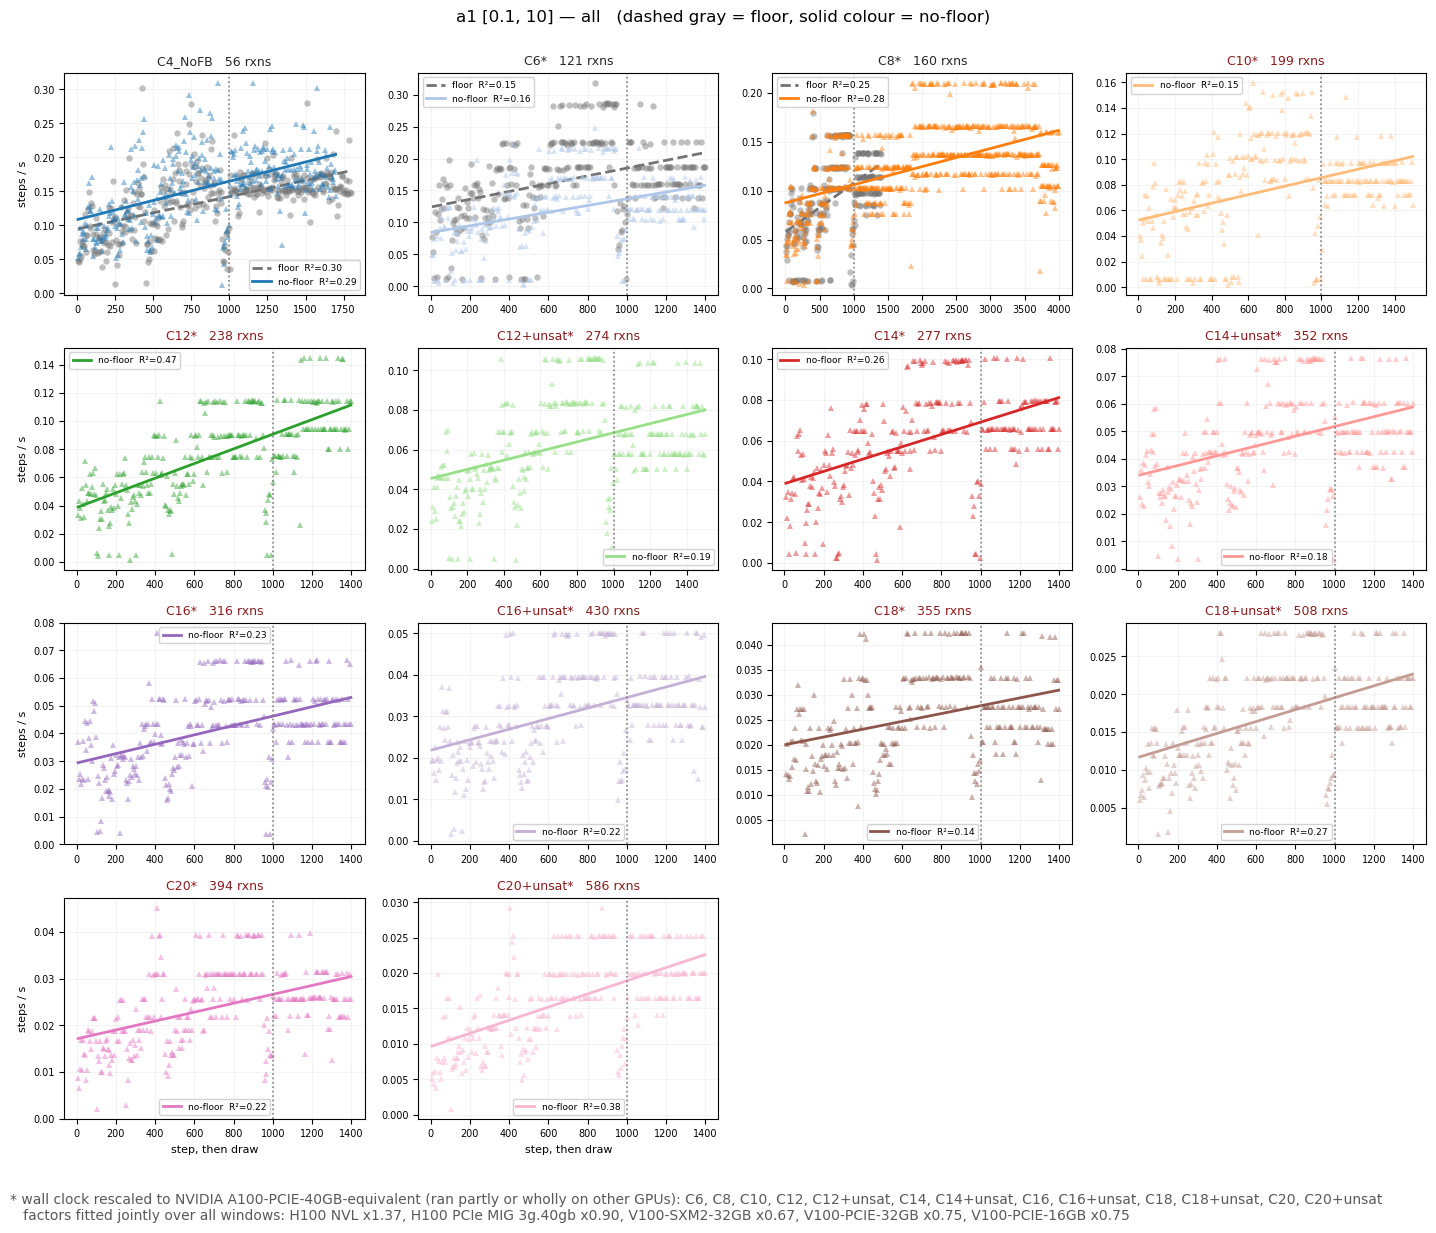

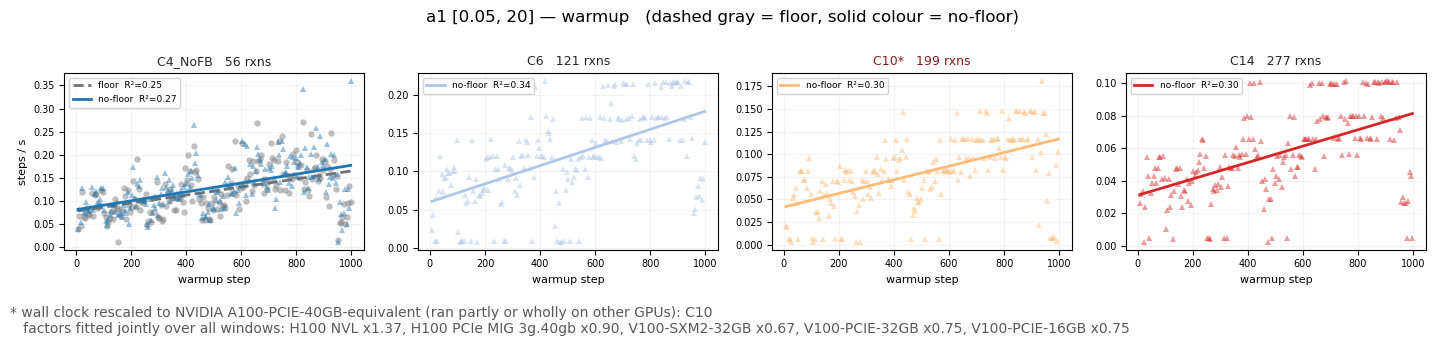

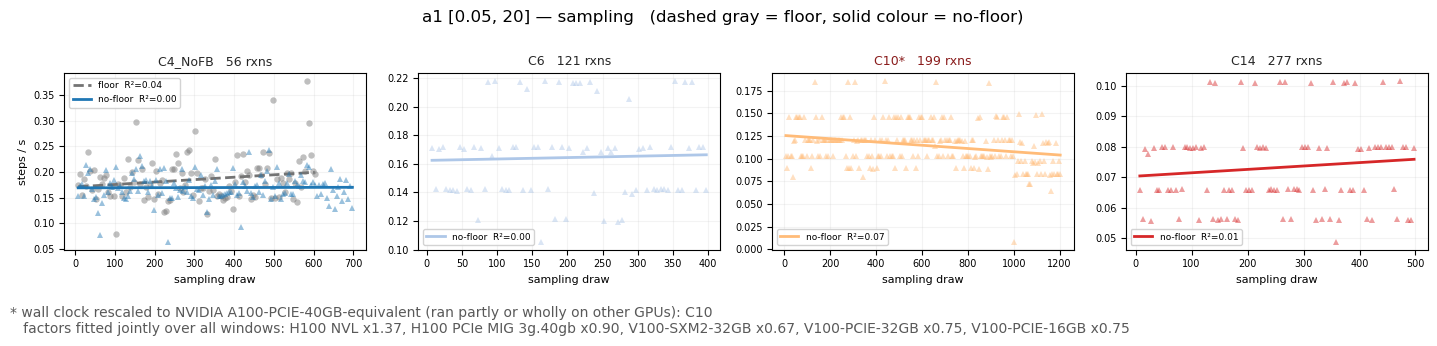

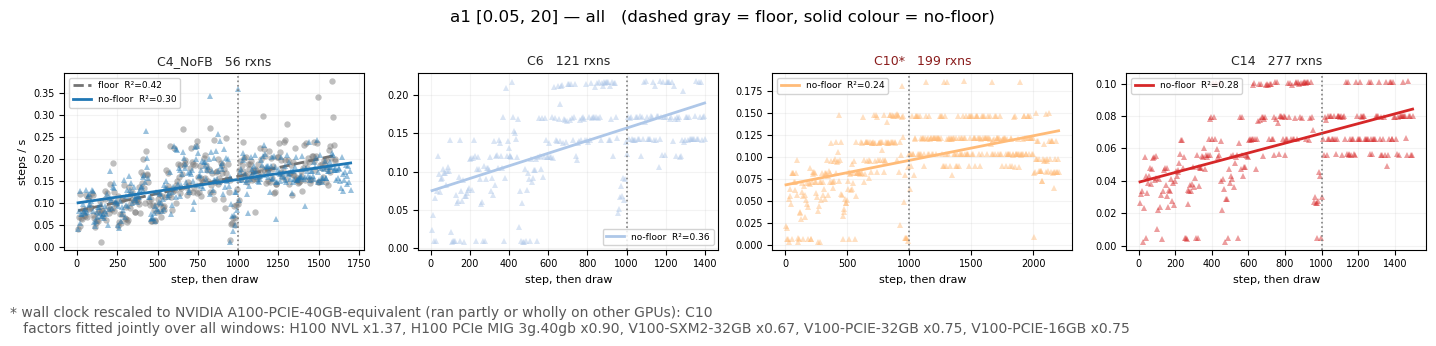

In [6]:
def small_multiples(label, fset, nset, phase, ncols=4):
    systems = [s for s in systems_in(fset, nset)
               if len(rate_curve(fset, s, phase)[0]) or len(rate_curve(nset, s, phase)[0])]
    if not systems:
        print(f"{label} / {phase}: nothing yet")
        return
    nrows = int(np.ceil(len(systems) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 2.9 * nrows),
                             squeeze=False)
    for ax in axes.flat:
        ax.set_visible(False)

    for i, s in enumerate(systems):
        ax = axes[i // ncols][i % ncols]
        ax.set_visible(True)
        for setkey, style, marker, colour, cond in (
                (fset, "--", "o", "0.45", "floor"),
                (nset, "-", "^", COLOR[s], "no-floor")):
            x, y = rate_curve(setkey, s, phase)
            if not len(x):
                continue
            ax.plot(x, y, marker, ms=4.6, mew=0, alpha=.45, color=colour)
            if len(x) >= MIN_POINTS:
                _, r2, predict = fit_rate(x, y)
                gx = np.linspace(x.min(), x.max(), 50)
                ax.plot(gx, predict(gx), style, lw=2.0, color=colour,
                        label=f"{cond}  R\u00b2={r2:.2f}")
            else:
                ax.plot([], [], style, lw=2.0, color=colour, label=f"{cond}  (few pts)")
        if phase == "all":
            nt = n_tune_of(fset, s) or n_tune_of(nset, s)
            ax.axvline(nt, color="0.5", ls=":", lw=1.2)
        if LOG_RATE:
            ax.set_yscale("log")
        rx = N_REACTIONS.get(s)
        dead_here = [c for setk, c in ((fset, "floor"), (nset, "no-floor"))
                     if is_dead(setk, s)]
        st = "*" if (was_adjusted(fset, s) or was_adjusted(nset, s)) else ""
        ax.set_title(f"{s}{st}" + (f"   {rx} rxns" if rx else ""), fontsize=9,
                     color="0.15" if not dead_here else "#8a1c1c")
        ax.grid(alpha=.15, which="both")
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6.5, framealpha=.85, loc="best")
        if i // ncols == nrows - 1:
            ax.set_xlabel({"warmup": "warmup step", "sampling": "sampling draw",
                           "all": "step, then draw"}[phase], fontsize=8)
        if i % ncols == 0:
            ax.set_ylabel("steps / s", fontsize=8)

    fig.suptitle(f"{label} — {phase}   (dashed gray = floor, solid colour = no-floor)",
                 fontsize=12, y=1.0)
    hw_note(fig, fset, nset, systems)
    plt.tight_layout(); plt.show()


for label, fset, nset in COMPARISONS:
    for ph in PHASES:
        small_multiples(label, fset, nset, ph)

## Why the floor is slow: cost per solve, not amount of work

Steps-per-second conflates two different things. A NUTS iteration contains
anywhere from 1 to 100+ leapfrog steps, and each one needs its own ODE solve.

Over the first 50 draws the floor takes **fewer** integrator steps than no-floor
(C10: 400 vs 1271; C12: 320 vs 889) yet runs ~20x slower in wall clock. So it is
not doing more work — each unit of work costs it ~50x more, because every solve
grinds to `max_steps`.

The step-size panel shows the consequence: dual averaging, finding nothing
acceptable, drives the floor's step size down seven orders of magnitude in
eleven draws while no-floor settles at ~1e-2.

Two passes below. First **both conditions capped at 8h of A100-equivalent compute**,
which is the equal-budget comparison — what each gets for the same spend. Then
**no-floor alone, uncapped**, over each run's full history: with one condition there is
nothing to equalise, and the cap would only discard the deepest part of every run.


compute cap: 30h A100-equivalent  (this section only)
PRIOR      SYSTEM      COND       ckpts  within cap   steps
------------------------------------------------------------
a1         C4_NoFB     floor        200         200    1000
a1         C4_NoFB     nofloor      200         200    1000
a1         C6          floor        200         200    1000
a1         C6          nofloor      200         200    1000
a1         C8          floor        200         200    1000
a1         C8          nofloor      200         200    1000
a1         C10         floor         31           0       0
a1         C10         nofloor      200         200    1000
a1         C12         floor          8           0       0
a1         C12         nofloor      200         200    1000
a1         C12+unsat   floor          7           0       0
a1         C12+unsat   nofloor      200         200    1000
a1         C14         floor          9           0       0
a1         C14         nofloor      200      

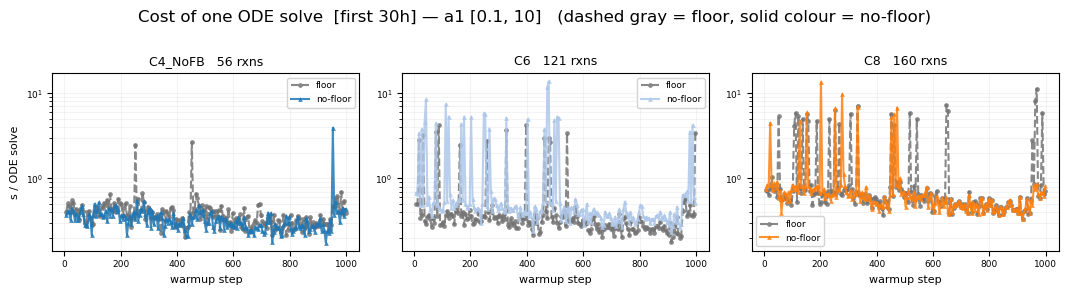

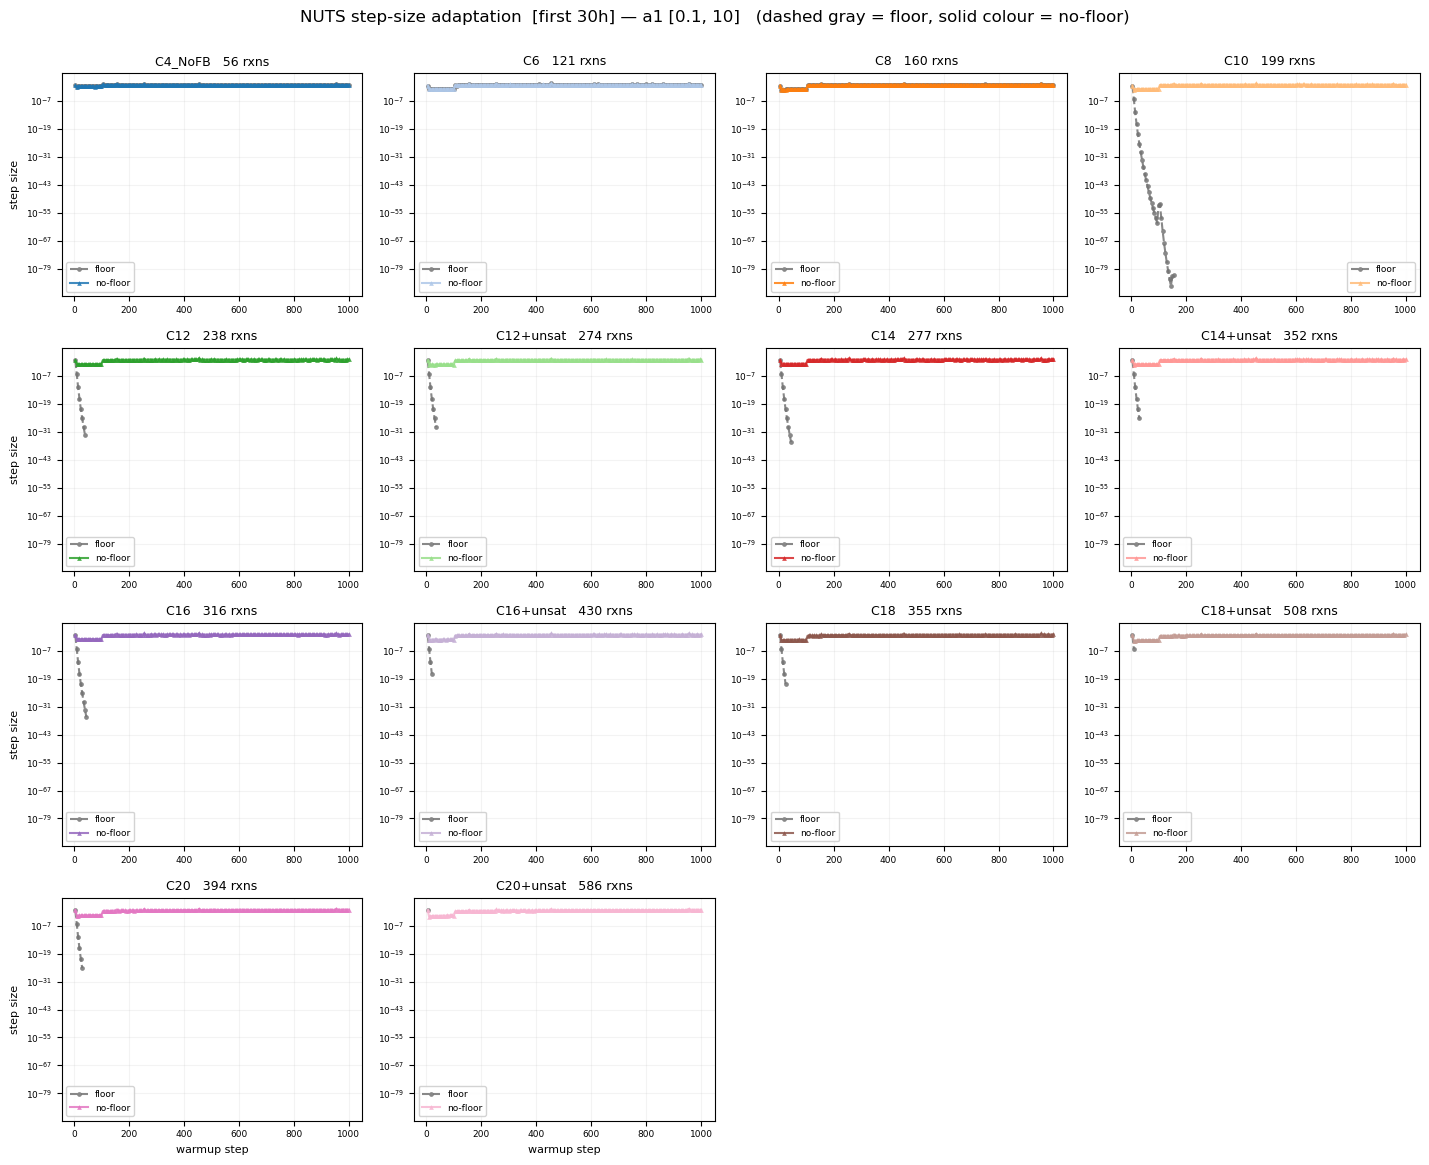

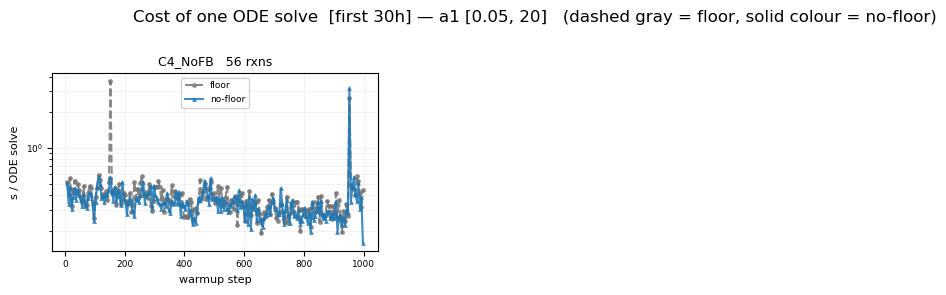

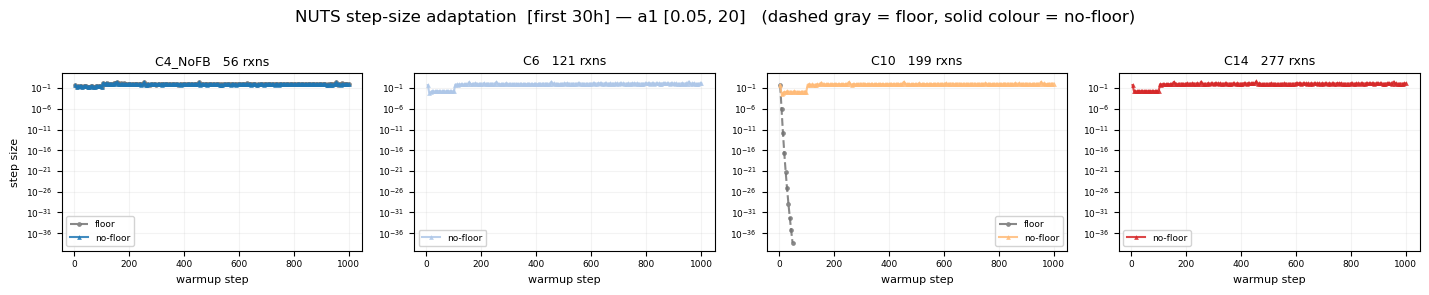

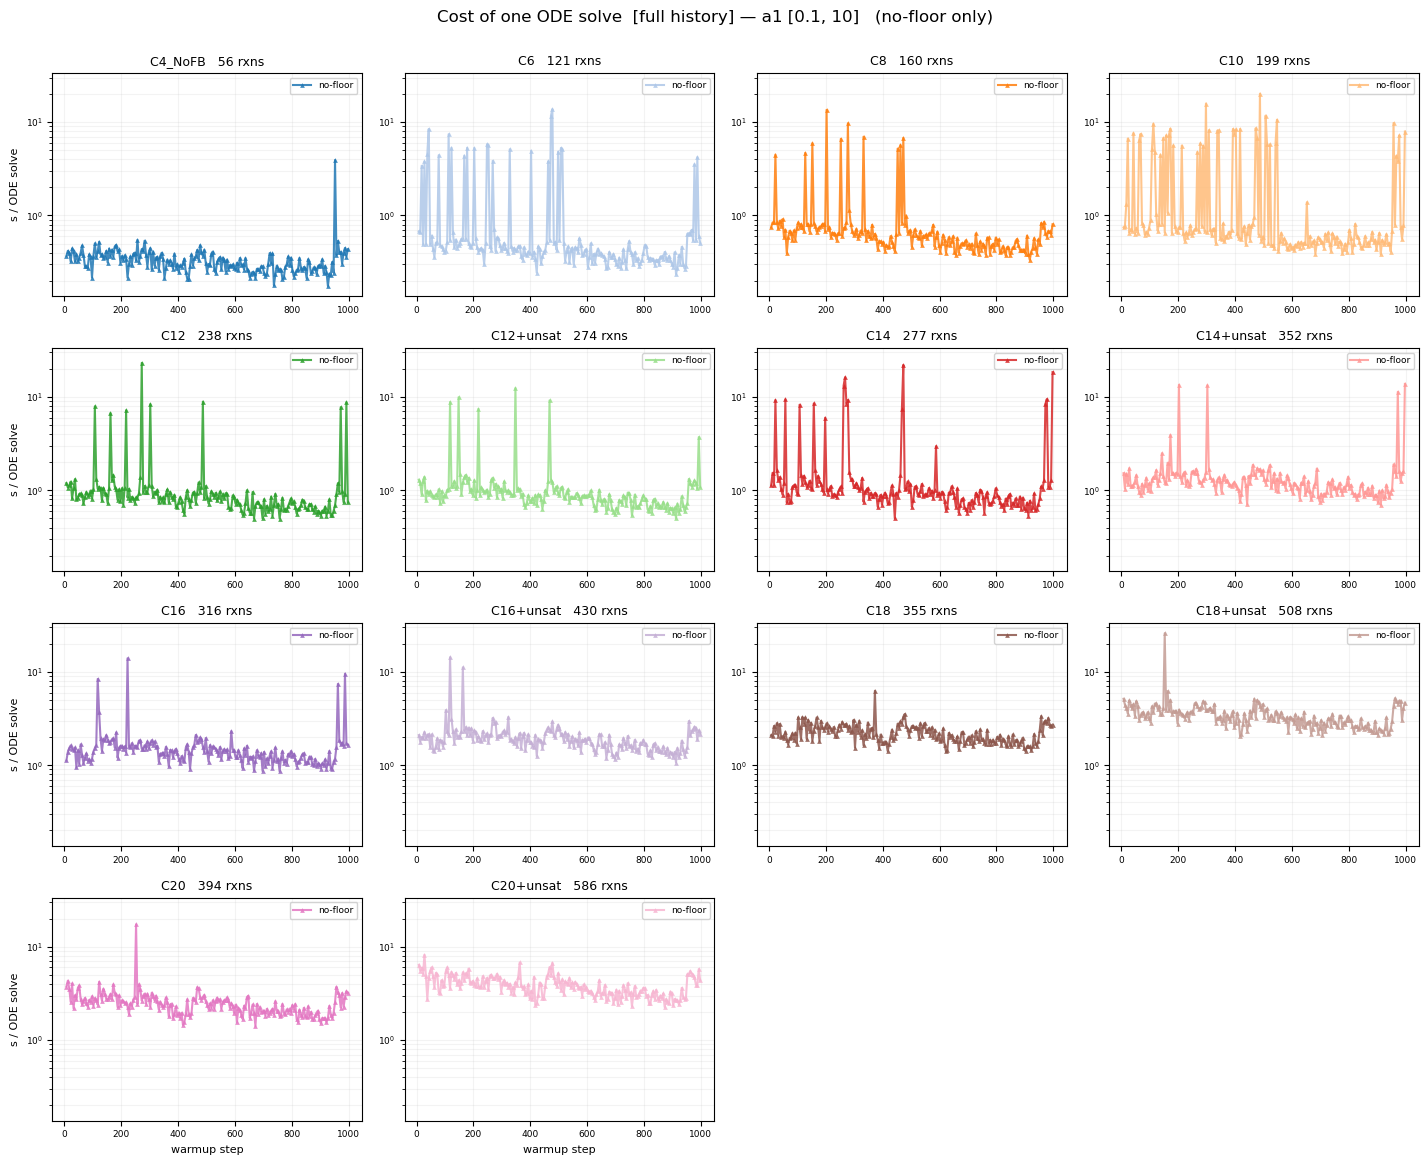

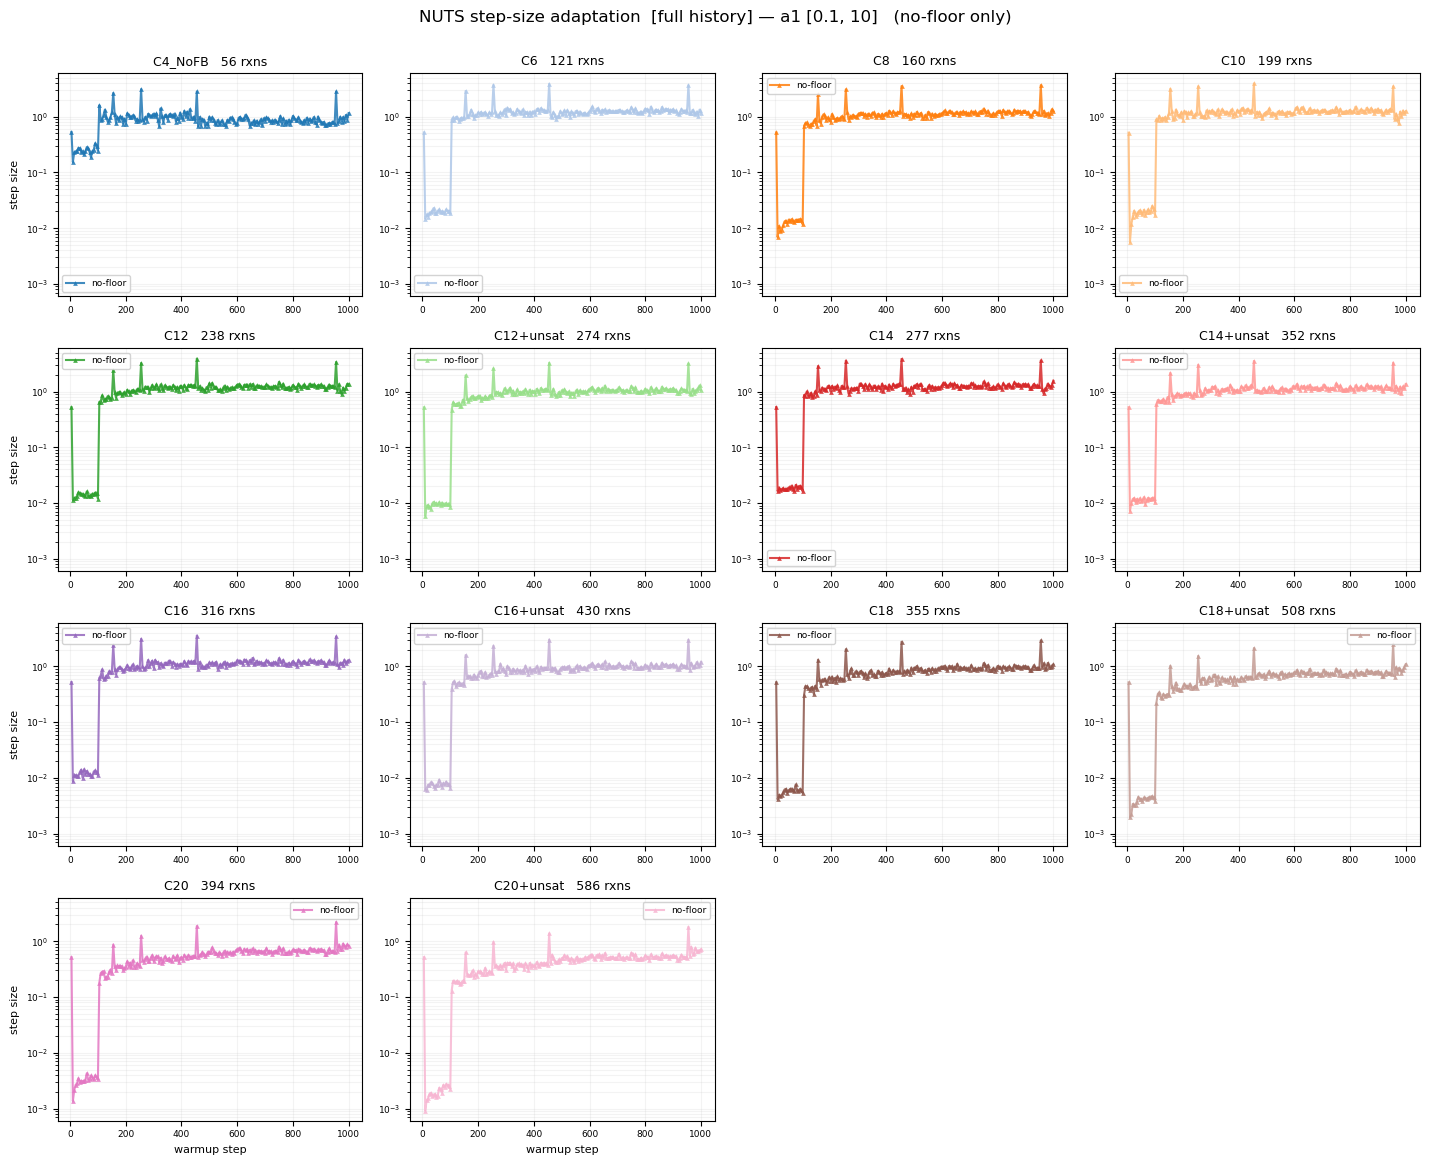

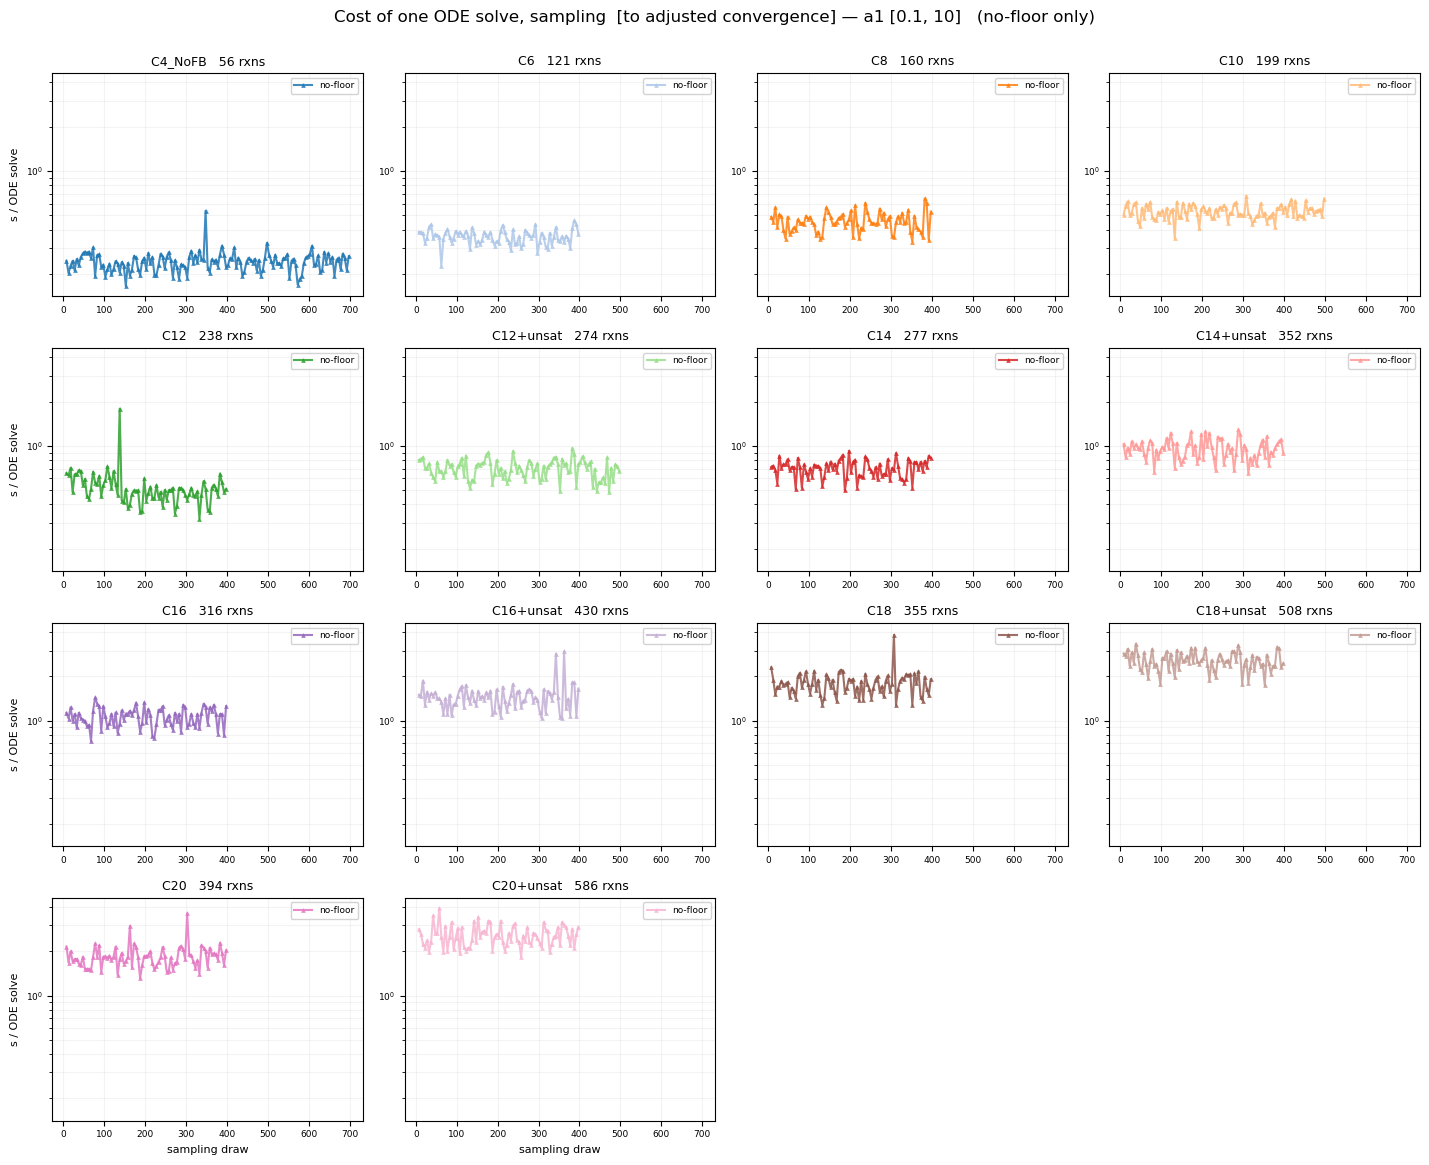

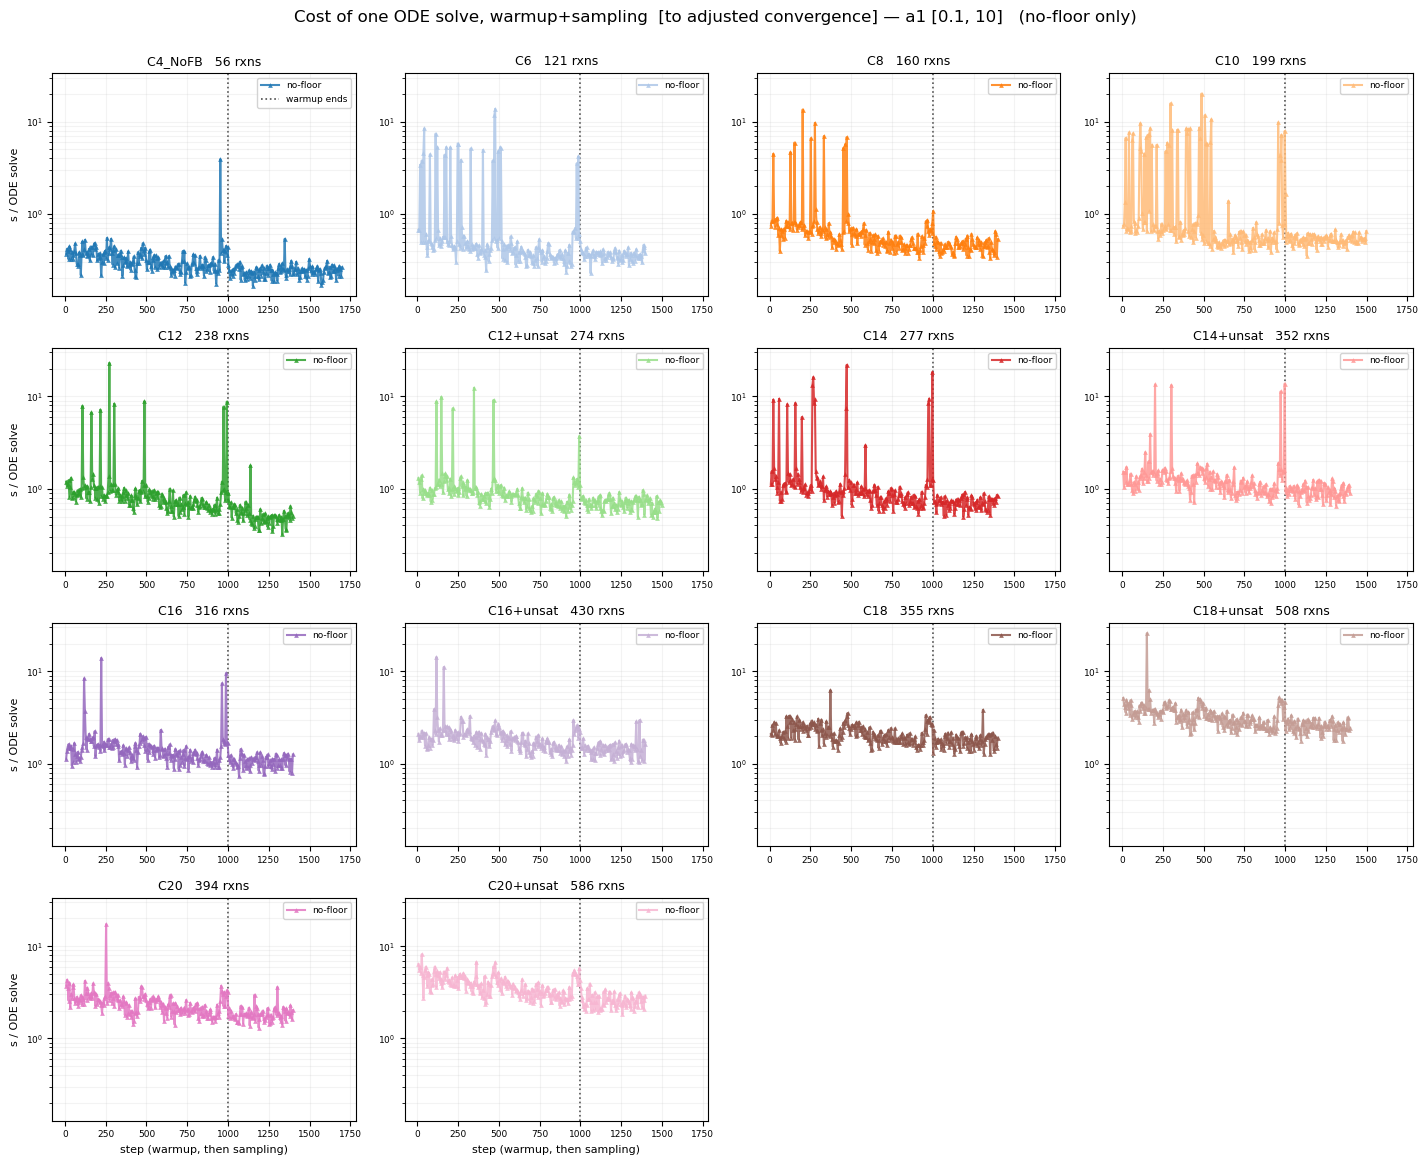

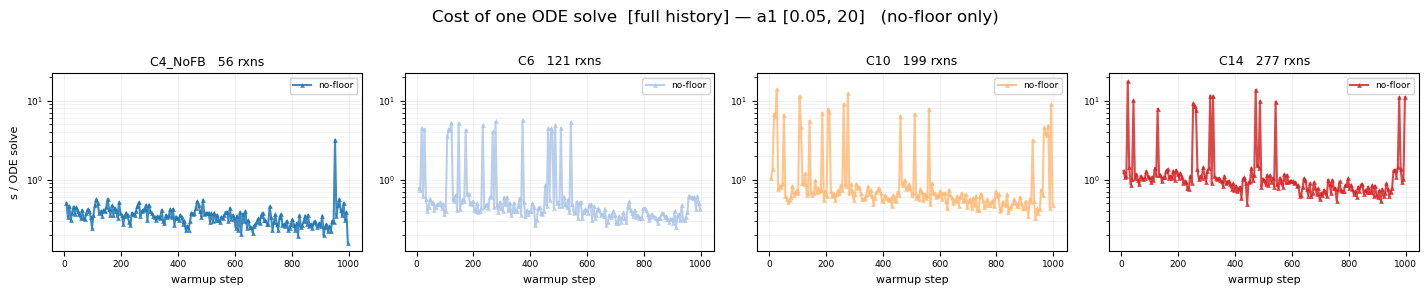

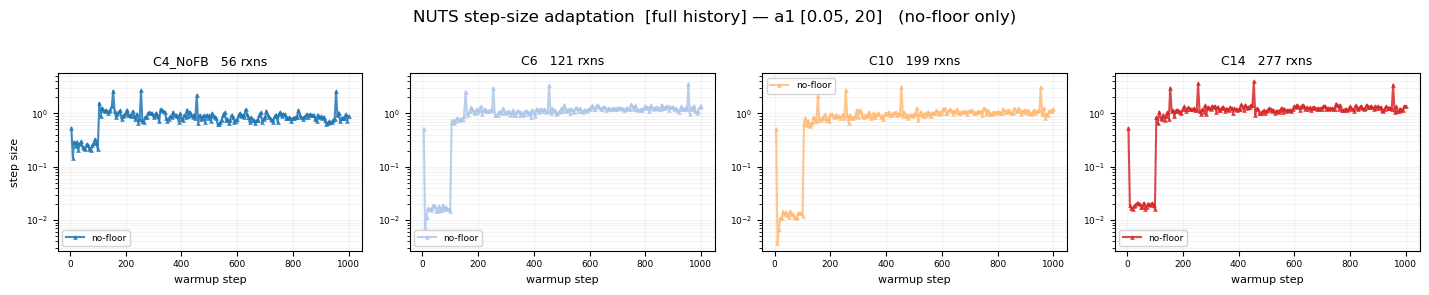

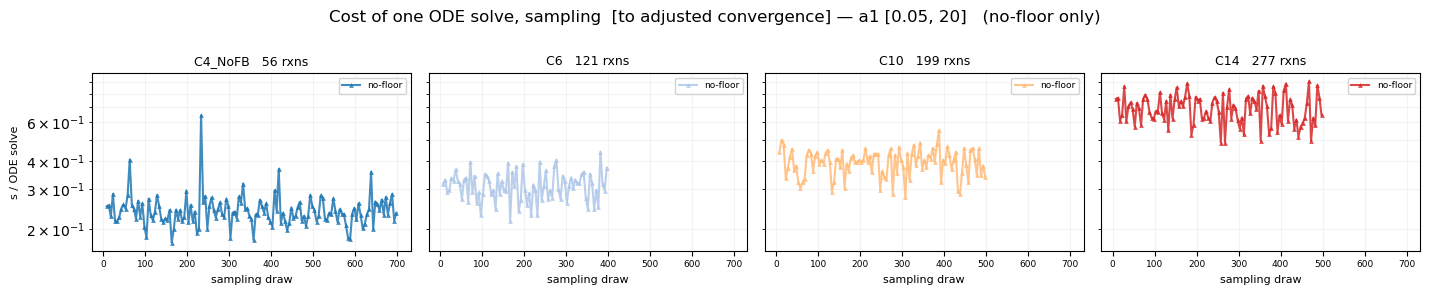

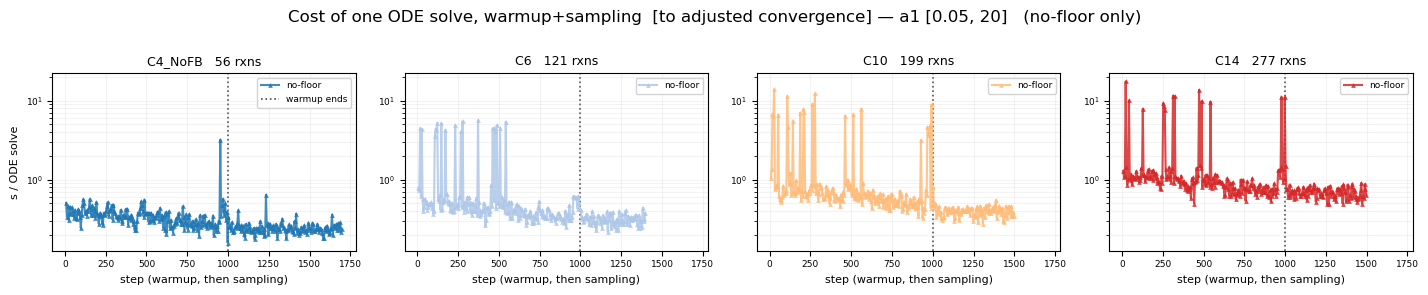

In [7]:
# Stranded-chain systems whose live run overshot true convergence: the live
# detector only excluded the stranded chain(s) late (it needs a sustained gap
# before flagging one), so the run kept sampling long after the OTHER chains
# alone had already converged -- e.g. C8 ran to 3000 sampling draws, but
# recomputing r-hat/ESS over its 7 good chains from the start shows 2
# consecutive passing checks by draw 300. Defined here (not just in the ladder
# leaderboard section below, which reuses this) because any cost-per-solve
# view that includes the sampling phase needs the same adjusted convergence
# point too -- without it, these systems' plots would run hundreds of draws
# past the point that actually mattered. 2026-09-10.
# Re-verified 2026-09-16 against the scaled ESS rule (bulk ESS >= 100 x chains, from
# Vehtari et al. 2021's >= 50 per split chain) rather than the flat 400 these were first
# derived under. Each netcdf holds only its kept chains, so the bar follows that count:
# C8 7 chains -> 700, C6-narrowest 6 -> 600, C10-narrowest 4 -> 400. Recomputing on the
# production block grid (every rhat_check_every draws, two consecutive passing checks,
# then one further block) confirms 400 for C8 and C6-narrowest, unchanged.
#
# C10-narrowest recomputes to 400 against the 500 recorded here, and that gap is NOT from
# the rule change -- its 4 chains put its bar at 400, exactly the old flat value, so both
# rules agree. The 500 predates this check and is left alone deliberately: shortening its
# window would drop 100 draws from the a1 recovery stats below, which is an analysis
# decision rather than a figure correction. Worth resolving separately.
CONVERGED_SAMPLING_DONE_OVERRIDE = {
    ("tightest_nofloor", "C8"): 400,
    ("narrowest_nofloor", "C6"): 400,
    ("narrowest_nofloor", "C10"): 500,
}


def converged_sampling_cap(setkey, system):
    """Per-chain sampling draw index to stop at for a stranded-chain system,
    else None (no cap -- the run's own live data already stops at the right
    point)."""
    return CONVERGED_SAMPLING_DONE_OVERRIDE.get((setkey, system))


def phase_cap(setkey, system, phase):
    """converged_sampling_cap, translated into whatever index space `phase`
    uses -- a raw draw index for "sampling", offset past n_tune for "all"."""
    override = converged_sampling_cap(setkey, system)
    if override is None or phase == "warmup":
        return None
    return override if phase == "sampling" else n_tune_of(setkey, system) + override


def diag_multiples(label, fset, nset, phase, what, ylab, title,
                   only=None, require_both=False, logy=True, ncols=4):
    """only=None plots both conditions; only="nofloor" plots that one alone.

    With a single condition on the panel, colour is free to encode system again
    rather than condition, so the no-floor-only pass keeps the per-system colour.

    require_both drops systems that have live data for only one condition. The
    cost-per-solve comparison needs it: above C8 every floor run is dead and
    contributes no cost points, so those panels would show a lone no-floor trace
    that the uncapped no-floor pass already covers.
    """
    if only == "nofloor":
        systems = [s for s in systems_in(fset, nset)
                   if len(rate_curve(nset, s, phase)[0])]
    elif require_both:
        systems = [s for s in systems_in(fset, nset)
                   if len(rate_curve(fset, s, phase)[0]) and len(rate_curve(nset, s, phase)[0])]
    else:
        systems = [s for s in systems_in(fset, nset)
                   if len(rate_curve(fset, s, phase)[0]) or len(rate_curve(nset, s, phase)[0])]
    if not systems:
        return
    nrows = int(np.ceil(len(systems) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 2.9 * nrows),
                             squeeze=False, sharex=True, sharey=True)
    for ax in axes.flat:
        ax.set_visible(False)
    xlab = {"warmup": "warmup step", "sampling": "sampling draw",
           "all": "step (warmup, then sampling)"}.get(phase, phase)
    for i, s in enumerate(systems):
        ax = axes[i // ncols][i % ncols]; ax.set_visible(True)
        specs = ([(nset, "-", "^", COLOR[s], "no-floor")] if only == "nofloor"
                 else [(fset, "--", "o", "0.45", "floor"),
                       (nset, "-", "^", COLOR[s], "no-floor")])
        for setk, style, mk, col, cond in specs:
            if what == "cost":
                x, y = cost_per_solve(setk, s, phase, cap=phase_cap(setk, s, phase))
            else:
                allowed = set(phase_series(setk, s, phase, drop_dead=False))
                d = {k: v for k, v in block_stat(setk, s, phase, what).items()
                     if k in allowed}
                x = np.array(sorted(d)); y = np.array([d[k] for k in x], float)
                keep = y > 0
                x, y = x[keep], y[keep]
            if not len(x):
                continue
            ax.plot(x, y, style, marker=mk, ms=3.4, mew=0, lw=1.5,
                    color=col, alpha=.85, label=cond)
        if phase == "all":
            ax.axvline(n_tune_of(nset, s), color="0.3", ls=":", lw=1.2, zorder=0,
                       label="warmup ends" if i == 0 else None)
        if logy:
            ax.set_yscale("log")
        rx = N_REACTIONS.get(s)
        ax.set_title(f"{s}" + (f"   {rx} rxns" if rx else ""), fontsize=9)
        ax.grid(alpha=.15, which="both"); ax.tick_params(labelsize=7)
        ax.legend(fontsize=6.5, framealpha=.85, loc="best")
        if i // ncols == nrows - 1:
            ax.set_xlabel(xlab, fontsize=8)
        if i % ncols == 0:
            ax.set_ylabel(ylab, fontsize=8)
        ax.tick_params(labelbottom=True, labelleft=True, labelsize=6.5)
    sub = "no-floor only" if only == "nofloor" else "dashed gray = floor, solid colour = no-floor"
    fig.suptitle(f"{title} — {label}   ({sub})", fontsize=12, y=1.0)
    plt.tight_layout(); plt.show()


CAP_H = 30
with compute_cap(CAP_H):
    print(f"compute cap: {CAP_H}h A100-equivalent  (this section only)")
    print(f"{'PRIOR':<11}{'SYSTEM':<12}{'COND':<9}{'ckpts':>7}{'within cap':>12}"
          f"{'steps':>8}")
    print("-" * 60)
    for label, fset, nset in COMPARISONS:
        short = label.split()[0]
        for sy in systems_in(fset, nset):
            for setk, cond in ((fset, "floor"), (nset, "nofloor")):
                raw = DATA.get(setk, {}).get(sy, {}).get("warmup") or {}
                kept = phase_series(setk, sy, "warmup")
                if raw:
                    print(f"{short:<11}{sy:<12}{cond:<9}{len(raw):>7}{len(kept):>12}"
                          f"{(max(kept) if kept else 0):>8}")
    print("-" * 60)
    print("a floor row at 0 is dead-checkpoint filtering, not the cap\n")

    for label, fset, nset in COMPARISONS:
        diag_multiples(label, fset, nset, "warmup", "cost",
                       "s / ODE solve", f"Cost of one ODE solve  [first {CAP_H}h]",
                       require_both=True, ncols=3)
        diag_multiples(label, fset, nset, "warmup", "stepsize",
                       "step size", f"NUTS step-size adaptation  [first {CAP_H}h]")

for label, fset, nset in COMPARISONS:
    diag_multiples(label, fset, nset, "warmup", "cost",
                   "s / ODE solve", "Cost of one ODE solve  [full history]",
                   only="nofloor")
    diag_multiples(label, fset, nset, "warmup", "stepsize",
                   "step size", "NUTS step-size adaptation  [full history]",
                   only="nofloor")
    diag_multiples(label, fset, nset, "sampling", "cost",
                   "s / ODE solve", "Cost of one ODE solve, sampling  [to adjusted convergence]",
                   only="nofloor")
    diag_multiples(label, fset, nset, "all", "cost",
                   "s / ODE solve", "Cost of one ODE solve, warmup+sampling  [to adjusted convergence]",
                   only="nofloor")


## Throughput trend table

`MEDIAN` is the robust summary; `TREND` and `R2` come from the same fit the panels draw. A low R²
means the straight line is not describing the series — check `N` before quoting the trend.


In [8]:
import pandas as pd

rows = []
for label, fset, nset in COMPARISONS:
    short = label.split()[0]
    for phase in PHASES:
        for setk, cond in ((fset, "floor"), (nset, "nofloor")):
            for s in systems_in(fset, nset):
                x, y = rate_curve(setk, s, phase)
                if len(x) < MIN_POINTS:
                    continue
                trend, r2, _ = fit_rate(x, y)
                rows.append(dict(prior=short, phase=phase, cond=cond,
                                  system=s + star(setk, s), n=len(x),
                                  range=f"{x[0]:.0f}-{x[-1]:.0f}",
                                  median_per_s=round(float(np.median(y)), 4),
                                  trend=trend, r2=round(r2, 2)))
df_throughput = pd.DataFrame(rows)
if NORMALIZE_HW:
    print("* wall clock rescaled to " + REF_DEVICE + "-equivalent")
df_throughput

* wall clock rescaled to NVIDIA A100-PCIE-40GB-equivalent


,prior,phase,cond,system,n,range,median_per_s,trend,r2
0,a1,warmup,floor,C4_NoFB,199,8-998,0.1182,+0.0080/100st,0.21
1,a1,warmup,floor,C6*,199,8-998,0.1590,+0.0134/100st,0.29
2,a1,warmup,floor,C8,199,8-998,0.0869,+0.0079/100st,0.26
3,a1,warmup,nofloor,C4_NoFB,199,8-998,0.1280,+0.0092/100st,0.23
4,a1,warmup,nofloor,C6,199,8-998,0.1196,+0.0117/100st,0.30
...,...,...,...,...,...,...,...,...,...
61,a1,all,floor,C4_NoFB,320,8-1602,0.1487,+0.0079/100st,0.42
62,a1,all,nofloor,C4_NoFB,339,8-1698,0.1528,+0.0054/100st,0.30
63,a1,all,nofloor,C6,279,8-1398,0.1408,+0.0082/100st,0.36
64,a1,all,nofloor,C10*,440,8-2202,0.1029,+0.0028/100st,0.24


## Which chains actually converged, and all the inference plots

Everything above is timing. This section pulls what each chain actually **sampled** --
`a1` and the log-posterior `lp`, plus `acceptance_rate`/`n_steps` for the runs that
never got that far -- so two more questions can be answered directly instead of assumed:

1. Did every "converged" run's chains actually land in the same place? (the stranded-chain
   question -- r-hat/ESS can pass while one or more chains sit in a much lower-posterior
   basin; BFMI does not catch this either, tested directly against the C8 case)
2. For a run this table calls dead, what does "dead" actually look like, chain by chain?

`export_posterior_series.py` is the timing exporter's companion: same `warmup_status.SETS`
plumbing, but it dumps arrays, not `{step: seconds}` maps.

In [9]:
import subprocess, json as _json

REMOTE_POST = "/projects/anth4580/Bayesian/job_files/export_posterior_series.py"
LOCAL_POST = pathlib.Path("posterior.json")

proc = subprocess.run(["ssh", "curc", SRUN + f"{REMOTE_PY} {REMOTE_POST}"],
                      stdout=subprocess.PIPE, stderr=subprocess.PIPE)
if proc.returncode != 0:
    raise RuntimeError(proc.stderr.decode()[-2000:])

LOCAL_POST.write_bytes(proc.stdout)
POST = _json.loads(proc.stdout)
print(f"{LOCAL_POST} <- {len(proc.stdout)/1024:.1f} KB")
for setname, systems in POST.items():
    print(f"  {setname:<20} {len(systems):>2} systems")

PRIOR_BOUNDS = {
    "tightest": (0.1, 10), "tightest_nofloor": (0.1, 10),
    "narrowest_matched": (0.05, 20), "narrowest_nofloor": (0.05, 20),
}
# Plot-facing display names: the actual numeric prior range instead of the
# internal "tightest"/"narrowest" codename, which means nothing to a reader
# who hasn't seen PRIOR_BOUNDS. Anything not listed here (the a1c2/a1c3
# multi-parameter pilot sets) falls back to its own setkey unchanged.
PRIOR_LABEL = {
    "tightest": "[0.1, 10] (floor)", "tightest_nofloor": "[0.1, 10] (no-floor)",
    "narrowest_matched": "[0.05, 20] (floor)", "narrowest_nofloor": "[0.05, 20] (no-floor)",
}
GAP_NATS = 20.0   # same threshold resumable_sampler.py uses to exclude a stranded chain


def chain_summary(setkey, system):
    """(a1, lp, accept, n_steps) arrays (chains, draws) + kept/stranded chain
    indices + a dead_frozen flag, or None if this (set, system) has no data.

    dead_frozen mirrors the same criterion the sampler itself uses for a dead
    chain: every recorded acceptance is ~0 AND every recorded leapfrog count
    is exactly 1 (one rejected proposal per iteration, position never moves).
    Checked directly against the arrays here, not trusted from a separate
    status query -- see the warmup_status.py fix note below for why that
    distinction mattered tonight.
    """
    rec = POST.get(setkey, {}).get(system)
    if not rec or "error" in rec:
        return None
    # params is {name: (chains, draws)} for however many free parameters this
    # run has (a1 alone on the ladder; a1+c2 or a1+c3 for the multi-parameter
    # pilot). a1 is kept as its own top-level key too, since every stranded-
    # chain/a1-trace plot in this notebook was written against a single-
    # parameter world and reads cs["a1"] directly.
    params = {name: np.array(arr) for name, arr in rec["params"].items()}
    a1 = params.get("a1")
    lp = np.array(rec["lp"])
    accept = np.array(rec.get("accept", [])); n_steps = np.array(rec.get("n_steps", []))
    step_size = np.array(rec["step_size"]) if "step_size" in rec else None
    # Trailing window, not the full history: warmup is non-stationary (step
    # size and mass matrix are still adapting), so a chain that lagged early
    # and fully caught up would otherwise read as permanently stranded --
    # exactly what happened to C16+unsat/C18/C20+unsat here (gaps of 25.8,
    # 128.8, 3827 nats over the FULL history collapsed to 0.2-0.4 nats once
    # measured over just the last window). A genuinely stranded chain (C8,
    # C10-narrowest) is unaffected by this -- it never catches up, so the
    # trailing window and the full history agree.
    window = min(200, max(20, lp.shape[1] // 4))
    means = lp[:, -window:].mean(axis=1)
    gaps = means.max() - means
    stranded = [c for c in range(len(means)) if gaps[c] > GAP_NATS]
    kept = [c for c in range(len(means)) if c not in stranded]
    dead_frozen = bool(accept.size and n_steps.size
                       and accept.mean() < 1e-6 and (n_steps == 1).all())
    return dict(a1=a1, params=params, lp=lp, accept=accept, n_steps=n_steps,
                step_size=step_size, kept=kept, stranded=stranded, gaps=gaps,
                source=rec["source"], n_chains=rec["n_chains"], dead_frozen=dead_frozen)

posterior.json <- 6158.7 KB
  tightest             14 systems
  tightest_nofloor     14 systems
  narrowest_matched     2 systems
  narrowest_nofloor     4 systems
  a1c2_no_floor         3 systems
  a1c3_no_floor         3 systems
  a1c3a2_no_floor       3 systems
  a1c3d1_no_floor       3 systems


In [10]:
_rows = []
for setkey in POST:
    for system in POST[setkey]:
        cs = chain_summary(setkey, system)
        if cs is None:
            continue
        kept_a1 = cs["a1"][cs["kept"]] if cs["kept"] else np.array([])
        stranded_a1 = cs["a1"][cs["stranded"]] if cs["stranded"] else np.array([])
        _rows.append(dict(
            prior=setkey, system=system, source=cs["source"], n_chains=cs["n_chains"],
            n_stranded=len(cs["stranded"]),
            worst_gap_nats=round(float(cs["gaps"].max()), 1),
            kept_a1_mean=round(float(kept_a1.mean()), 4) if kept_a1.size else None,
            kept_a1_std=round(float(kept_a1.std()), 4) if kept_a1.size else None,
            stranded_a1_mean=round(float(stranded_a1.mean()), 4) if stranded_a1.size else None,
            dead_frozen=cs["dead_frozen"],
        ))
df_chains = pd.DataFrame(_rows).sort_values(["prior", "system"]).reset_index(drop=True)
print("configs with a detected stranded chain (excluded from convergence diagnostics,")
print("kept in the saved draws -- see resumable_sampler.py's lp-gap exclusion):")
df_chains[df_chains["n_stranded"] > 0]

configs with a detected stranded chain (excluded from convergence diagnostics,
kept in the saved draws -- see resumable_sampler.py's lp-gap exclusion):


,prior,system,source,n_chains,n_stranded,worst_gap_nats,kept_a1_mean,kept_a1_std,stranded_a1_mean,dead_frozen
9,a1c3d1_no_floor,C10,warmup,8,3,84.4,1.1289,0.1712,1.7555,False
10,a1c3d1_no_floor,C14,warmup,8,5,948.2,1.1029,0.1218,1.5000,False
12,narrowest_matched,C10,warmup,8,7,17664.4,1.3794,0.0000,4.1049,True
14,narrowest_nofloor,C10,sampling,8,4,6975.3,0.9984,0.0168,9.4141,False
17,narrowest_nofloor,C6,sampling,8,2,6134.7,0.9998,0.0160,10.7202,False
18,tightest,C10,warmup,8,7,17078.6,0.8553,0.0000,2.5451,True
19,tightest,C12,warmup,8,7,3095.9,0.8553,0.0000,2.5451,True
20,tightest,C12+unsat,warmup,8,7,5823.2,0.8553,0.0000,2.5451,True
21,tightest,C14,warmup,8,7,2173.6,0.8553,0.0000,2.5451,True
22,tightest,C14+unsat,warmup,8,7,4670.5,0.8553,0.0000,2.5451,True


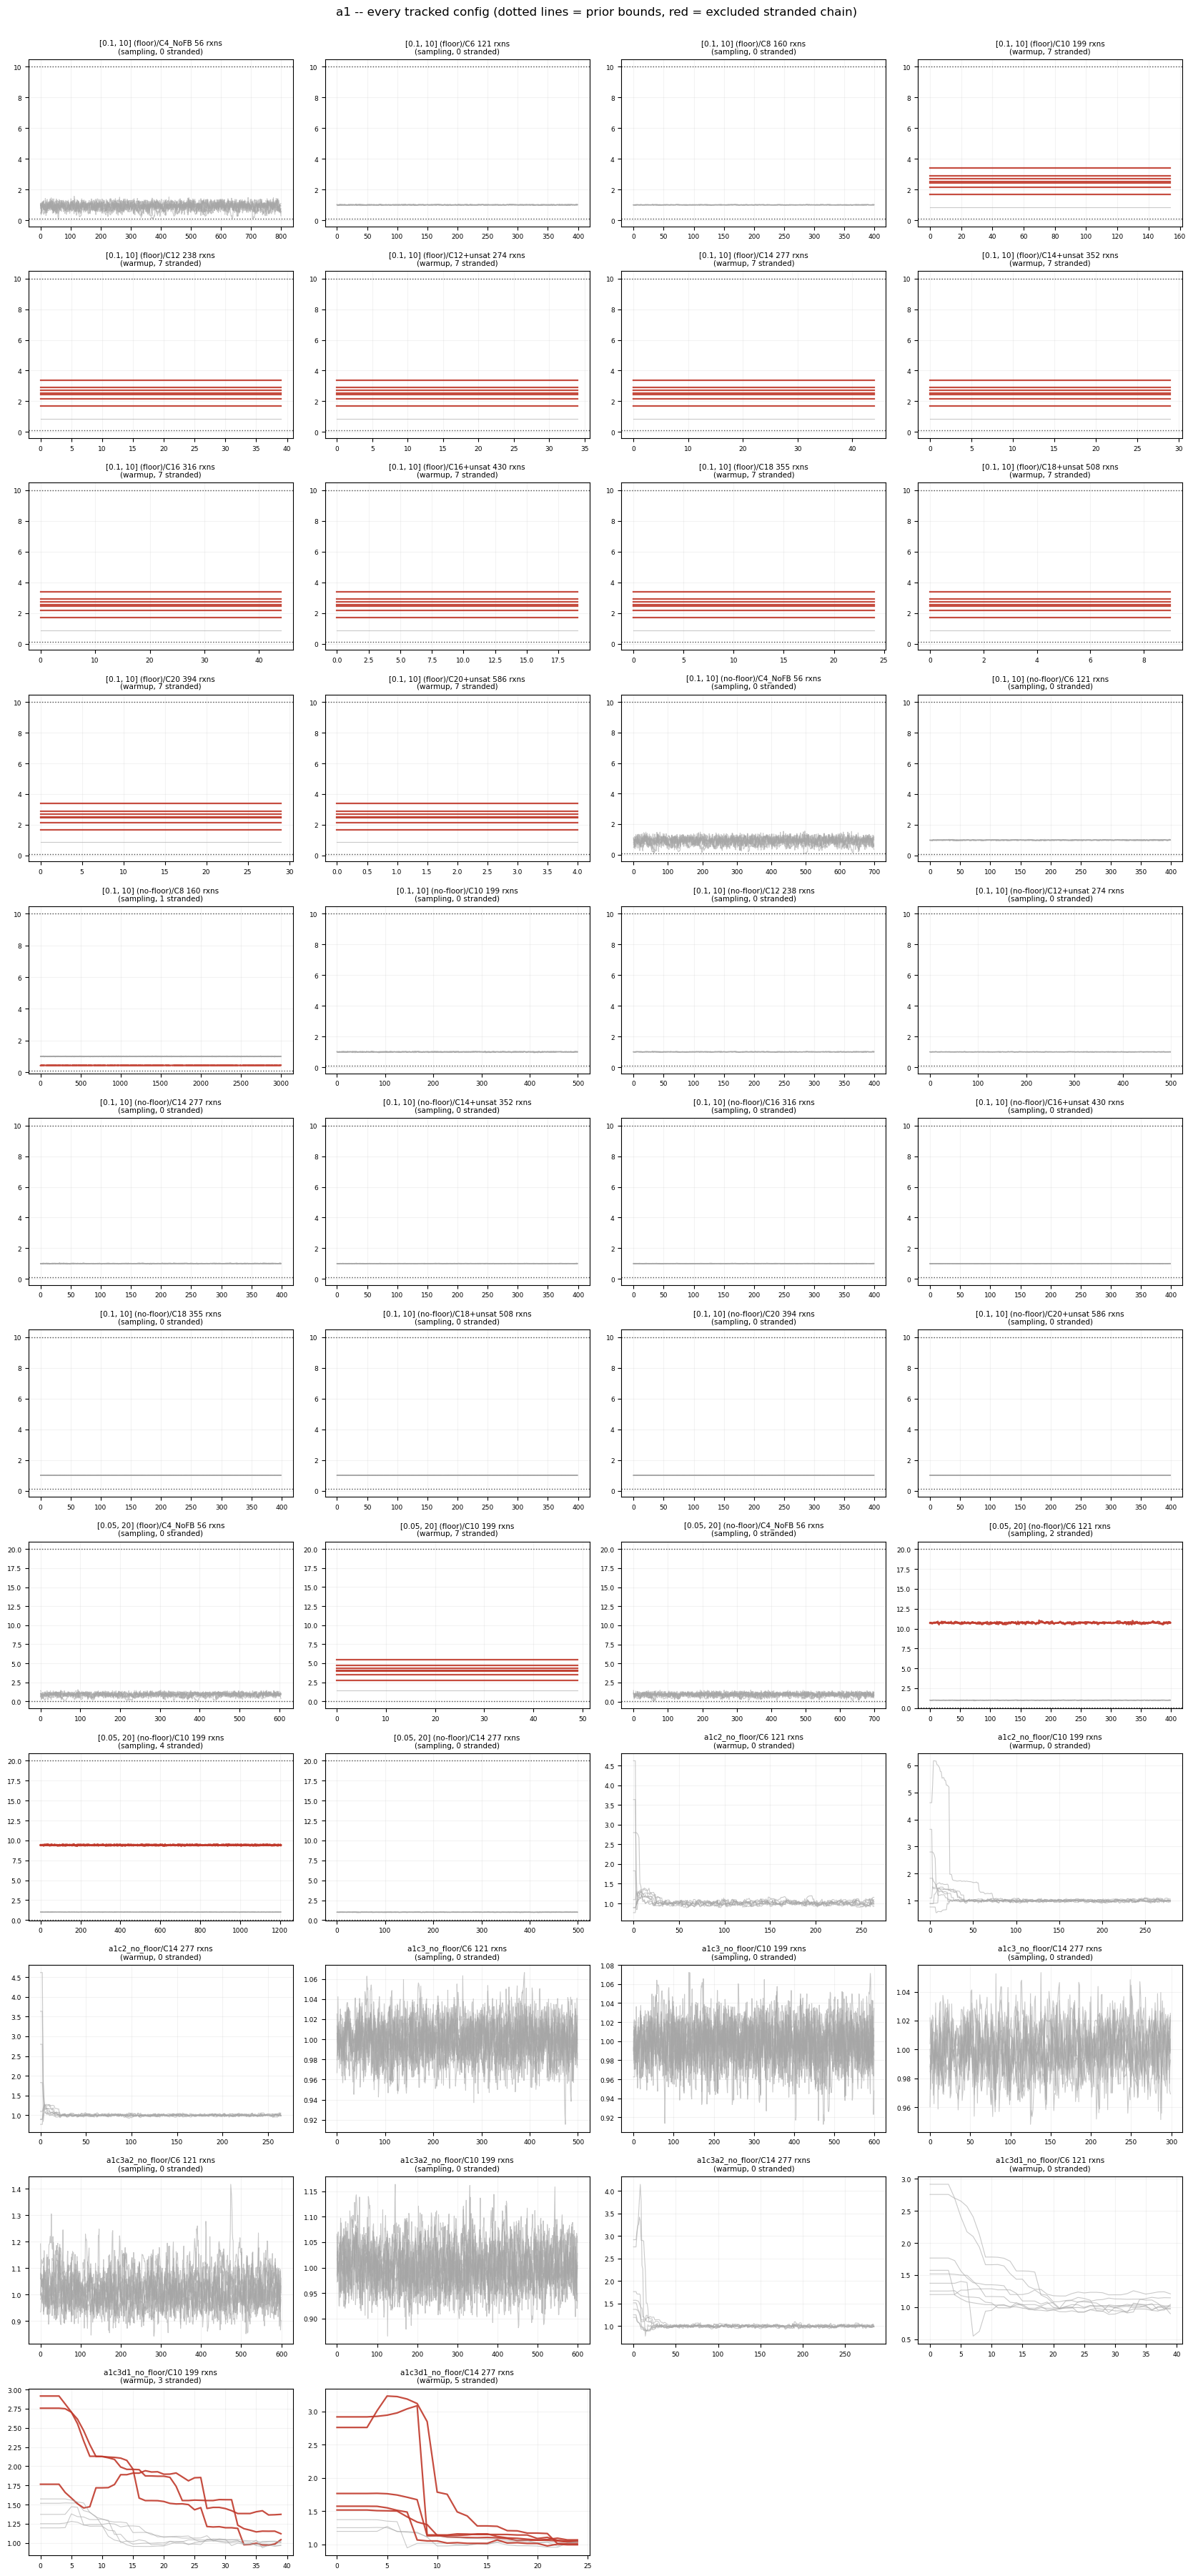

In [11]:
def inference_sweep_figure(configs, ncols=4, title=""):
    """a1 trace, one panel per (set, system). Kept chains in grey, a stranded
    chain in red -- this doubles as the "all inference plots" sweep (a1 is
    the only free parameter right now, so its trace IS the inference plot)
    and as the visual for the stranded-chain finding: a red line sits flat
    and separate from the grey band rather than mixing into it.
    """
    n = len(configs)
    if n == 0:
        return
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.0 * nrows), squeeze=False)
    for ax in axes.flat:
        ax.set_visible(False)
    for i, (setkey, system) in enumerate(configs):
        ax = axes[i // ncols][i % ncols]; ax.set_visible(True)
        cs = chain_summary(setkey, system)
        if cs is None:
            continue
        a1 = cs["a1"]
        for c in range(a1.shape[0]):
            stranded = c in cs["stranded"]
            ax.plot(a1[c], color="#c0392b" if stranded else "0.65",
                    lw=1.6 if stranded else 0.8, alpha=0.9 if stranded else 0.6)
        lo, hi = PRIOR_BOUNDS.get(setkey, (None, None))
        if hi is not None:
            ax.axhline(hi, color="0.3", ls=":", lw=1)
            ax.axhline(lo, color="0.3", ls=":", lw=1)
        rx = N_REACTIONS.get(system)
        rx_note = f" {rx} rxns" if rx else ""
        src, n_str = cs["source"], len(cs["stranded"])
        set_label = PRIOR_LABEL.get(setkey, setkey)
        ax.set_title(f"{set_label}/{system}{rx_note}\n({src}, {n_str} stranded)", fontsize=7.5)
        ax.tick_params(labelsize=6.5)
        ax.grid(alpha=.15)
    fig.suptitle(title, fontsize=12, y=1.0)
    plt.tight_layout(); plt.show()


all_configs = [(sk, s) for sk in POST for s in POST[sk]]
inference_sweep_figure(all_configs, title="a1 -- every tracked config "
                       "(dotted lines = prior bounds, red = excluded stranded chain)")

### Stranded chains: is the lp gap real, or sampling noise?

`chain_summary()` calls a chain "stranded" when its trailing-window lp sits more
than `GAP_NATS` (20 nats) below the best chain's. The two clearest examples on
the ladder, zoomed in below rather than buried in the all-configs sweep above:

- **`tightest_nofloor`/C8** -- 1 of 8 chains parks at a1≈0.43 instead of ≈1.0,
  ~533 nats of lp below the other seven, for the entire recorded sampling phase.
- **`narrowest_nofloor`/C10** -- 4 of 8 chains park at a1≈9.3 (against the wider
  `[0.05,20]` prior's own ceiling) instead of ≈1.0, ~6,975 nats of lp below the
  other four -- the largest split found anywhere on the ladder.

Both gaps are two to three orders of magnitude past the 20-nat threshold, and
both are flat for the whole window, not a transient dip a longer run would
close. Since lp is log-likelihood + log-prior, a gap this size means the model
predicts the data dramatically worse at that chain's parameter value -- a real
competing mode, not "unlucky sampling," on a single-parameter, no-op-truth
system (a1=1) that has no business supporting one. Both are excluded from the
recovery statistics below via `chain_summary()["kept"]`.

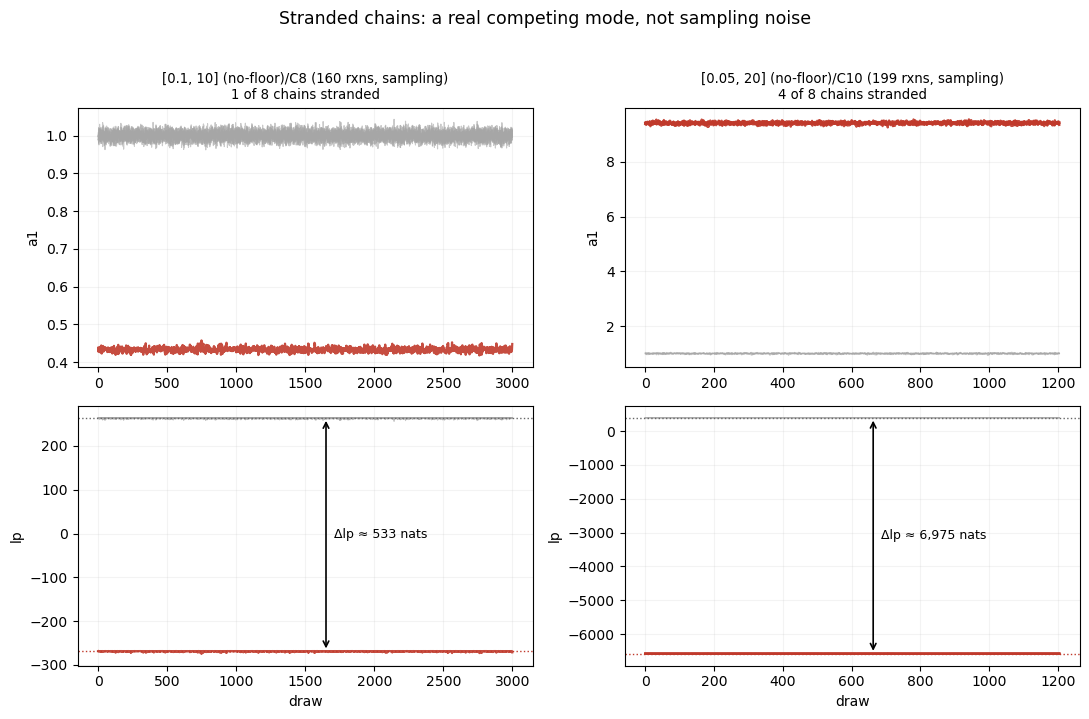

In [12]:
def stranded_chain_figure(examples, title="Stranded chains: a real competing mode, not sampling noise"):
    """a1 (top) and lp (bottom) traces for hand-picked (set, system) examples that
    each contain a stranded chain, with the trailing-window lp gap -- the same
    number chain_summary() thresholds against -- annotated directly on the lp
    panel. Kept chains in grey, stranded in red, same convention as
    inference_sweep_figure, but zoomed to the two clearest cases so the gap is
    readable rather than one line among many in the all-configs sweep.
    """
    n = len(examples)
    fig, axes = plt.subplots(2, n, figsize=(5.5 * n, 7.0), squeeze=False)
    for j, (setkey, system) in enumerate(examples):
        cs = chain_summary(setkey, system)
        ax_a1, ax_lp = axes[0][j], axes[1][j]
        if cs is None:
            for ax in (ax_a1, ax_lp):
                ax.text(.5, .5, "no data", ha="center", va="center", transform=ax.transAxes)
            continue
        a1, lp = cs["a1"], cs["lp"]
        for c in range(a1.shape[0]):
            stranded = c in cs["stranded"]
            color, lw, alpha = ("#c0392b", 1.6, 0.9) if stranded else ("0.65", 0.8, 0.6)
            ax_a1.plot(a1[c], color=color, lw=lw, alpha=alpha)
            ax_lp.plot(lp[c], color=color, lw=lw, alpha=alpha)
        rx = N_REACTIONS.get(system)
        set_label = PRIOR_LABEL.get(setkey, setkey)
        ax_a1.set_title(f"{set_label}/{system} ({rx} rxns, {cs['source']})\n"
                        f"{len(cs['stranded'])} of {cs['n_chains']} chains stranded", fontsize=9.5)
        ax_a1.set_ylabel("a1"); ax_lp.set_ylabel("lp"); ax_lp.set_xlabel("draw")
        ax_a1.grid(alpha=.15); ax_lp.grid(alpha=.15)

        # Same trailing window chain_summary() used to call this chain stranded,
        # drawn as reference lines so the annotated gap is the threshold number.
        window = min(200, max(20, lp.shape[1] // 4))
        kept_level = lp[cs["kept"], -window:].mean()
        stranded_level = lp[cs["stranded"], -window:].mean()
        gap = kept_level - stranded_level
        ax_lp.axhline(kept_level, color="0.4", ls=":", lw=1)
        ax_lp.axhline(stranded_level, color="#c0392b", ls=":", lw=1)
        xmid = lp.shape[1] * 0.55
        ax_lp.annotate("", xy=(xmid, kept_level), xytext=(xmid, stranded_level),
                       arrowprops=dict(arrowstyle="<->", color="black", lw=1.2))
        ax_lp.text(xmid, (kept_level + stranded_level) / 2,
                   f"  \u0394lp \u2248 {gap:,.0f} nats", fontsize=9, va="center")
    fig.suptitle(title, fontsize=12.5, y=1.02)
    plt.tight_layout(); plt.show()


stranded_chain_figure([("tightest_nofloor", "C8"), ("narrowest_nofloor", "C10")])

### Why some runs are called dead, not slow

`is_dead()` earlier in this notebook, and `warmup_status.py`'s DIED status, both rest on
one criterion: every chain at ~0% acceptance. This makes that criterion visible directly,
chain by chain, next to a healthy run on the same three metrics -- rather than trusting
the label.

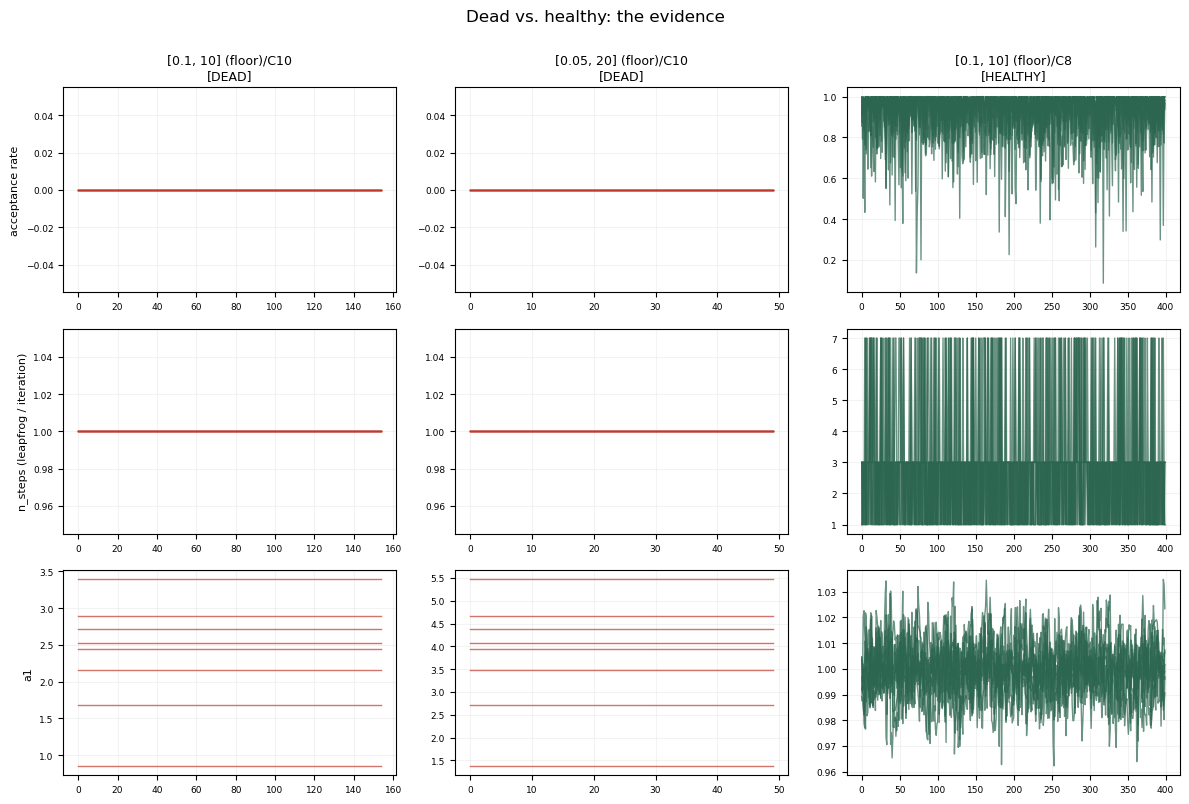

In [13]:
def dead_evidence_figure(dead_examples, healthy_example, title="Dead vs. healthy: the evidence"):
    cols = dead_examples + [healthy_example]
    fig, axes = plt.subplots(3, len(cols), figsize=(4.0 * len(cols), 8.0), squeeze=False)
    row_labels = ["acceptance rate", "n_steps (leapfrog / iteration)", "a1"]
    for j, (setkey, system) in enumerate(cols):
        cs = chain_summary(setkey, system)
        is_healthy = (setkey, system) == healthy_example
        tag = "HEALTHY" if is_healthy else ("DEAD" if cs and cs["dead_frozen"] else "?")
        for i, (arr_key, ax) in enumerate(zip(("accept", "n_steps", "a1"), axes[:, j])):
            if cs is None:
                ax.text(.5, .5, "no data", ha="center", va="center", transform=ax.transAxes)
                continue
            arr = cs[arr_key]
            for c in range(arr.shape[0]):
                ax.plot(arr[c], lw=1, alpha=.7, color="#c0392b" if not is_healthy else "#2c6650")
            if i == 0:
                set_label = PRIOR_LABEL.get(setkey, setkey)
                ax.set_title(f"{set_label}/{system}\n[{tag}]", fontsize=9)
            ax.tick_params(labelsize=6.5); ax.grid(alpha=.15)
            if j == 0:
                ax.set_ylabel(row_labels[i], fontsize=8)
    fig.suptitle(title, fontsize=12, y=1.0)
    plt.tight_layout(); plt.show()


# Smallest-reaction-count dead examples (clearest to read), next to the largest
# converged floor system as the healthy comparison.
_dead = sorted([(sk, s) for sk in POST for s in POST[sk]
               if chain_summary(sk, s) and chain_summary(sk, s)["dead_frozen"]],
              key=lambda c: N_REACTIONS.get(c[1], 999))[:2]
_healthy_candidates = [(sk, s) for sk, s in [("tightest", "C8"), ("tightest_nofloor", "C8")]
                       if chain_summary(sk, s) and not chain_summary(sk, s)["dead_frozen"]]
if _dead and _healthy_candidates:
    dead_evidence_figure(_dead, _healthy_candidates[0])
else:
    print("no dead examples or no healthy comparison found in the current pull")

## a1 recovery across the full chain-length ladder (Tier-1, synthetic truth a1=1)

Every system on the ladder is Tier-1: the training data was generated at a1=1
(a no-op scaling value), so "does the posterior recover 1.0" has a known answer
here, unlike the eventual Tier-2 fit to real data. Stats below pool each
system's *kept* chains only (`chain_summary()["kept"]`), so C8's rogue chain and
C10-narrowest's 4-chain split above are excluded, matching how
`resumable_sampler.py` itself would report convergence.

Each system's draws run from the start of sampling to where the run stopped. For
the three systems whose stranded chain let the live run keep sampling past its
real convergence point, the window ends at that point instead
(`CONVERGED_SAMPLING_DONE_OVERRIDE`: C8 and C6-narrowest at 400 draws,
C10-narrowest at 500) -- the same window their saved netcdfs use, so every
system's recovery is measured over a comparable number of post-convergence draws.

Prior sd is the LogNormal(median=1, sigma)'s natural-space standard deviation.
With the median pinned to 1 (as `_build_pymc_model()`'s
`pz.maxent(lower, upper, mass=0.95, fixed_stat=["median", 1.0])` call does for
every run here), that reduces to a plain two-sided normal-quantile match in log
space -- `sigma = log(upper) / norm.ppf(0.975)` -- checked against preliz's own
output to 5 decimal places, so no extra prior draws are needed, just the
`PRIOR_BOUNDS` already defined above.

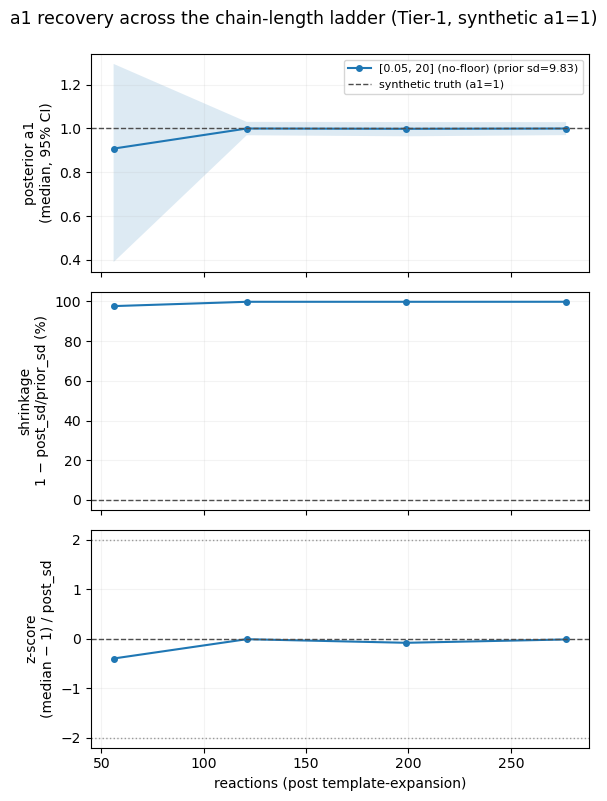

In [14]:
from scipy.stats import norm

def prior_sd(setkey):
    """Natural-space sd of a1's actual LogNormal(median=1, sigma) prior for this
    set, derived analytically from PRIOR_BOUNDS rather than pulled prior draws --
    see the markdown above for why the median=1 pin makes this exact."""
    lo, hi = PRIOR_BOUNDS[setkey]
    sigma = np.log(hi) / norm.ppf(0.975)
    return float(np.sqrt((np.exp(sigma ** 2) - 1) * np.exp(sigma ** 2)))


def shrinkage_ladder_figure(setkeys, title="a1 recovery across the chain-length ladder (Tier-1, synthetic a1=1)"):
    """Three panels vs. reaction count, one line per setkey: posterior median a1
    (with 95% CI band) against the a1=1 truth; prior-to-posterior shrinkage
    (1 - post_sd/prior_sd); and z-score ((median - 1)/post_sd). All three pool
    each system's kept chains only, via chain_summary(), up to the run's real
    convergence point where CONVERGED_SAMPLING_DONE_OVERRIDE has one.
    """
    fig, (ax_med, ax_shrink, ax_z) = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
    for setkey in setkeys:
        systems = sorted(POST.get(setkey, {}), key=chain_key)
        rx, med, lo95, hi95, shrink, z = [], [], [], [], [], []
        for system in systems:
            cs = chain_summary(setkey, system)
            if cs is None or cs["a1"] is None or not cs["kept"]:
                continue
            a1 = cs["a1"]
            cap = converged_sampling_cap(setkey, system)
            if cap is not None and cs["source"] == "sampling":
                a1 = a1[:, :cap]
            kept_a1 = a1[cs["kept"]].flatten()
            m, s = float(np.median(kept_a1)), float(kept_a1.std())
            rx.append(N_REACTIONS.get(system, np.nan)); med.append(m)
            lo95.append(np.percentile(kept_a1, 2.5)); hi95.append(np.percentile(kept_a1, 97.5))
            shrink.append(1 - s / prior_sd(setkey)); z.append((m - 1) / s)
        order = np.argsort(rx)
        rx, med = np.array(rx)[order], np.array(med)[order]
        lo95, hi95 = np.array(lo95)[order], np.array(hi95)[order]
        shrink, z = np.array(shrink)[order], np.array(z)[order]
        label = f"{PRIOR_LABEL.get(setkey, setkey)} (prior sd={prior_sd(setkey):.2f})"
        ax_med.plot(rx, med, "o-", ms=4, label=label)
        ax_med.fill_between(rx, lo95, hi95, alpha=0.15)
        ax_shrink.plot(rx, shrink * 100, "o-", ms=4, label=label)
        ax_z.plot(rx, z, "o-", ms=4, label=label)
    ax_med.axhline(1.0, color="0.3", ls="--", lw=1, label="synthetic truth (a1=1)")
    ax_med.set_ylabel("posterior a1\n(median, 95% CI)"); ax_med.legend(fontsize=8)
    ax_shrink.axhline(0, color="0.3", ls="--", lw=1)
    ax_shrink.set_ylabel("shrinkage\n1 \u2212 post_sd/prior_sd (%)")
    ax_z.axhline(0, color="0.3", ls="--", lw=1)
    for y in (-2, 2):
        ax_z.axhline(y, color="0.6", ls=":", lw=1)
    ax_z.set_ylabel("z-score\n(median \u2212 1) / post_sd")
    ax_z.set_xlabel("reactions (post template-expansion)")
    for ax in (ax_med, ax_shrink, ax_z):
        ax.grid(alpha=.15)
    fig.suptitle(title, fontsize=12.5, y=0.995)
    plt.tight_layout(); plt.show()


shrinkage_ladder_figure(["narrowest_nofloor"])

## Floor vs no-floor, measured directly (not fit or extrapolated)

Floor has no live cost-per-solve data at all past C8 (dead everywhere above that, so
there is nothing to fit a trend to), and floor's **startup** cost is actually *larger*
than no-floor's at nearly every system checked, not smaller -- there is no clean
two-power-law crossover in the data explaining floor's edge at small systems.

What the data actually supports, shown directly below rather than fit: floor is
competitive-to-cheaper per solve at the three systems where it is even alive
(C4_NoFB/C6/C8), and no-floor wins decisively once floor's cliff hits (dead from C10 on).
Why floor edges out no-floor specifically at C6 in total sampling time (5.9 vs 8.4
s/draw) remains an open mechanistic question -- not answered by startup cost.

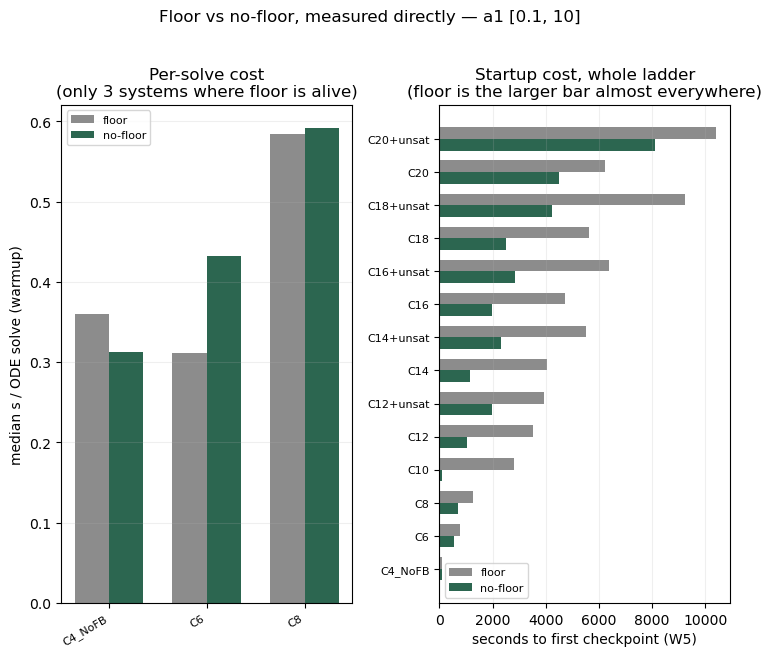

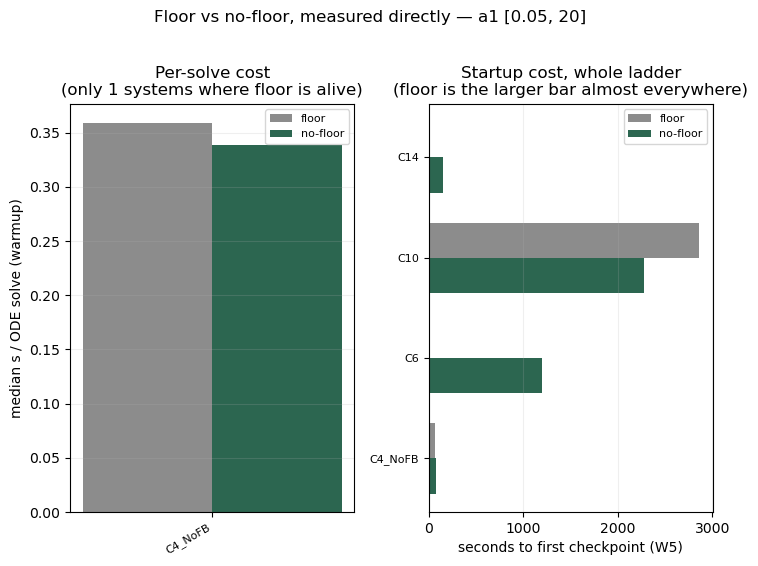

In [15]:
for label, fset, nset in COMPARISONS:
    cost_systems = [s for s in systems_in(fset, nset) if s in N_REACTIONS
                   and len(cost_per_solve(fset, s, "warmup")[0])
                   and len(cost_per_solve(nset, s, "warmup")[0])]
    startup_systems = [s for s in systems_in(fset, nset) if s in N_REACTIONS
                       and (startup_cost(fset, s) or startup_cost(nset, s))]
    if not cost_systems and not startup_systems:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(max(4, 0.9 * len(cost_systems)) + 3.5,
                                            max(4, 0.35 * len(startup_systems)) + 1.5))

    ax = axes[0]
    x = np.arange(len(cost_systems)); w = 0.35
    fvals = [np.median(cost_per_solve(fset, s, "warmup")[1]) for s in cost_systems]
    nvals = [np.median(cost_per_solve(nset, s, "warmup")[1]) for s in cost_systems]
    ax.bar(x - w/2, fvals, w, color="0.55", label="floor")
    ax.bar(x + w/2, nvals, w, color="#2c6650", label="no-floor")
    ax.set_xticks(x); ax.set_xticklabels(cost_systems, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("median s / ODE solve (warmup)")
    ax.set_title(f"Per-solve cost\n(only {len(cost_systems)} systems where floor is alive)")
    ax.legend(fontsize=8); ax.grid(alpha=.2, axis="y")

    ax = axes[1]
    y = np.arange(len(startup_systems)); h = 0.35
    fvals = [startup_cost(fset, s) for s in startup_systems]
    nvals = [startup_cost(nset, s) for s in startup_systems]
    ax.barh(y + h/2, [v or 0 for v in fvals], h, color="0.55", label="floor")
    ax.barh(y - h/2, [v or 0 for v in nvals], h, color="#2c6650", label="no-floor")
    ax.set_yticks(y); ax.set_yticklabels(startup_systems, fontsize=8)
    ax.set_xlabel("seconds to first checkpoint (W5)")
    ax.set_title("Startup cost, whole ladder\n(floor is the larger bar almost everywhere)")
    ax.legend(fontsize=8); ax.grid(alpha=.2, axis="x")

    fig.suptitle(f"Floor vs no-floor, measured directly — {label}", fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

## Ladder leaderboard: total time to convergence

One bar per system (no-floor only -- floor is dead everywhere above C8-C10, so a
floor/no-floor pair no longer earns its place here), sorted by reaction count. Each
bar is stacked by phase: warmup (grey) then sampling (green), so the two costs read
directly off the same bar instead of needing a separate chart. The sampling segment
is labeled with the per-chain draw count convergence was actually reached at --
override-corrected for the stranded-chain systems below, same as the total-time
number. A system that never converged gets a "did not converge" label instead of a
bar; its elapsed-so-far time isn't a measurement of anything.


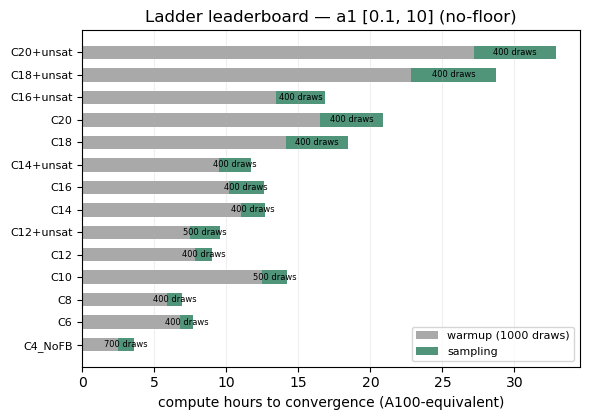

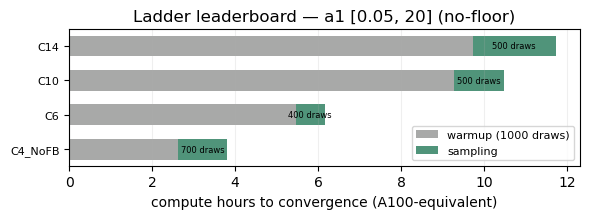

In [16]:
# CONVERGED_SAMPLING_DONE_OVERRIDE / converged_sampling_cap are defined above,
# in the cost-per-solve section -- reused here rather than redefined so the
# leaderboard and that section can never disagree about which systems get the
# stranded-chain correction.

def total_time_to_done(setkey, system):
    """Total compute seconds, but ONLY for a run that actually reached
    phase=="done" -- gated on converged_at, not just "does a time series
    exist". A dead/stalled run (C12+ under floor, e.g.) still logs warmup
    checkpoints and would otherwise read as a fast "convergence" here, which
    is exactly backwards: it never converged at all.

    The override systems bypass the converged_at gate deliberately: their
    progress_log.jsonl never got a final phase=="done" row written (killed at
    the wrong moment, same pattern as several missing-netcdf runs found
    2026-09-10) even though status.json/checkpoint_meta.json confirm phase
    "done" and the retroactive r-hat/ESS recomputation independently confirms
    real convergence -- converged_at being None there reflects a missing log
    line, not a real non-convergence.
    """
    rec = DATA.get(setkey, {}).get(system, {})
    if not rec:
        return None
    override = converged_sampling_cap(setkey, system)
    if override is None and rec.get("converged_at") is None:
        return None
    s = phase_series(setkey, system, "all", drop_dead=False)
    if not s:
        return None
    if override is not None:
        target = n_tune_of(setkey, system) + override
        candidates = [k for k in s if k >= target]
        if candidates:
            return s[min(candidates)]
    return max(s.values())


def samples_to_converge(setkey, system):
    """Per-chain sampling draws at the point convergence was actually reached.

    Same override as total_time_to_done, for the same reason: the stranded
    systems' own live draw count (e.g. C8's 3000) is the detector's catch-up
    lag, not the real convergence point. Returns None on the same conditions
    total_time_to_done bails on, so the two never disagree about whether a
    system converged.
    """
    rec = DATA.get(setkey, {}).get(system, {})
    if not rec:
        return None
    override = converged_sampling_cap(setkey, system)
    if override is None and rec.get("converged_at") is None:
        return None
    if override is not None:
        return override
    samp = phase_series(setkey, system, "sampling", drop_dead=False)
    return max(samp) if samp else None


WARMUP_COLOR, SAMPLING_COLOR = "#a8a9a8", "#50947a"

for label, fset, nset in COMPARISONS:
    systems = sorted([s for s in systems_in(fset, nset) if s in N_REACTIONS],
                     key=lambda s: N_REACTIONS[s])
    if not systems:
        continue
    fig, ax = plt.subplots(figsize=(6, 0.2 * len(systems) + 1.5))
    bar_h = 0.6
    for yi, s in enumerate(systems):
        total_t = total_time_to_done(nset, s)
        if not total_t:
            if is_dead(nset, s) or DATA.get(nset, {}).get(s, {}).get("warmup"):
                ax.text(0.01, yi, "did not converge", va="center", fontsize=7,
                        color="0.4", style="italic", transform=ax.get_yaxis_transform())
            continue
        warm = phase_series(nset, s, "warmup", drop_dead=False)
        nt = n_tune_of(nset, s)
        warmup_t = warm.get(nt) or 0.0
        sampling_t = max(total_t - warmup_t, 0.0)
        ax.barh(yi, warmup_t / 3600, height=bar_h, color=WARMUP_COLOR,
                label="warmup (1000 draws)" if yi == 0 else None)
        ax.barh(yi, sampling_t / 3600, height=bar_h, left=warmup_t / 3600,
                color=SAMPLING_COLOR, label="sampling" if yi == 0 else None)
        n_draws = samples_to_converge(nset, s)
        if n_draws:
            ax.text(warmup_t / 3600 + sampling_t / 3600 / 2, yi, f"{n_draws} draws",
                    ha="center", va="center", fontsize=6, color="black")
    ax.set_yticks(range(len(systems))); ax.set_yticklabels(systems, fontsize=8)
    ax.set_xlabel("compute hours to convergence (A100-equivalent)")
    ax.set_title(f"Ladder leaderboard — {label} (no-floor)")
    ax.legend(fontsize=8); ax.grid(alpha=.2, axis="x")
    plt.tight_layout(); plt.show()


## GPU device-factor cross-validation, visualized

Restates the three-method comparison already documented as a comment on `DEVICE_FACTORS`
above, as a chart rather than a table -- the star marks the adopted value.

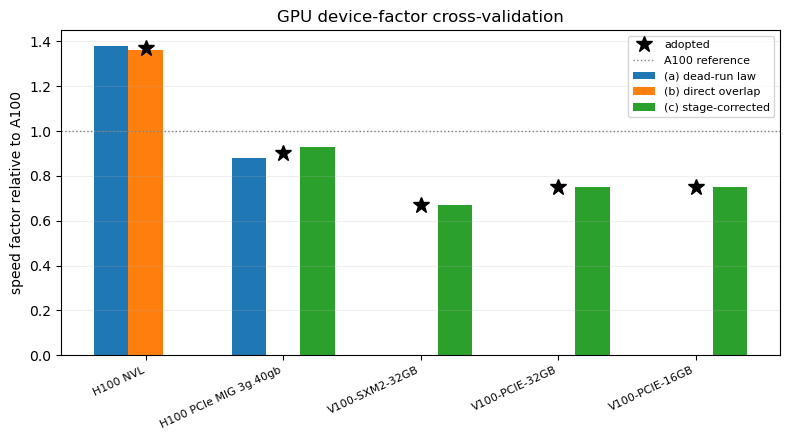

In [17]:
_FACTOR_METHODS = {
    "NVIDIA H100 NVL":              {"(a) dead-run law": 1.38, "(b) direct overlap": 1.36, "(c) stage-corrected": None},
    "NVIDIA H100 PCIe MIG 3g.40gb": {"(a) dead-run law": 0.88, "(b) direct overlap": None, "(c) stage-corrected": 0.93},
    "Tesla V100-SXM2-32GB":         {"(a) dead-run law": None, "(b) direct overlap": None, "(c) stage-corrected": 0.67},
    "Tesla V100-PCIE-32GB":         {"(a) dead-run law": None, "(b) direct overlap": None, "(c) stage-corrected": 0.75},
    "Tesla V100-PCIE-16GB":         {"(a) dead-run law": None, "(b) direct overlap": None, "(c) stage-corrected": 0.75},
}
_methods = ["(a) dead-run law", "(b) direct overlap", "(c) stage-corrected"]
_devices = list(_FACTOR_METHODS)
fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.25
for m_i, m in enumerate(_methods):
    xs = np.arange(len(_devices)) + (m_i - 1) * width
    ys = [_FACTOR_METHODS[d][m] for d in _devices]
    xs_plot = [x for x, y in zip(xs, ys) if y is not None]
    ys_plot = [y for y in ys if y is not None]
    ax.bar(xs_plot, ys_plot, width=width, label=m)
for i, d in enumerate(_devices):
    ax.plot(i, DEVICE_FACTORS[d], "k*", ms=12, zorder=5, label="adopted" if i == 0 else None)
ax.axhline(1.0, color="0.5", ls=":", lw=1, label="A100 reference")
ax.set_xticks(range(len(_devices)))
ax.set_xticklabels([d.replace("NVIDIA ", "").replace("Tesla ", "") for d in _devices],
                   rotation=25, ha="right", fontsize=8)
ax.set_ylabel("speed factor relative to A100")
ax.set_title("GPU device-factor cross-validation")
ax.legend(fontsize=8); ax.grid(alpha=.2, axis="y")
plt.tight_layout(); plt.show()

## Summary tables: raw wall-clock vs GPU-adjusted

One row per converged (prior, condition, system). `samples_per_chain` /
`total_samples_all_chains` distinguish per-chain draws from the pooled total across all
8 chains. `median_s_per_draw` uses the same windowed-rate methodology as the throughput
trend table above (median of `rate_curve`), not a naive total/count average.

First table: each run's own raw wall clock, un-normalized. Second: the same rows with
every time column rescaled to A100-equivalent (`NORMALIZE_HW`'s ordinary state) --
compare the two directly to see how much a run's hardware, not its condition, is
responsible for its number.

In [18]:
@contextmanager
def raw_clock():
    """Temporarily disable hardware normalization, for a table that wants
    each run's own raw wall-clock rather than A100-equivalent time."""
    global NORMALIZE_HW
    prev = NORMALIZE_HW
    NORMALIZE_HW = False
    try:
        yield
    finally:
        NORMALIZE_HW = prev


def build_summary_table():
    rows = []
    for label, fset, nset in COMPARISONS:
        for setk, cond in ((fset, "floor"), (nset, "nofloor")):
            for s in systems_in(fset, nset):
                rec = DATA.get(setk, {}).get(s, {})
                if not rec:
                    continue
                warm = phase_series(setk, s, "warmup", drop_dead=False)
                nt = n_tune_of(setk, s)
                warmup_time = warm.get(nt)
                samp = phase_series(setk, s, "sampling", drop_dead=False)
                if not samp or warmup_time is None:
                    continue
                n_chains_ = health(setk, s).get("n_chains") or 8
                samples_per_chain = max(samp)
                total_sampling_time = max(samp.values())
                x, y = rate_curve(setk, s, "sampling")
                median_s_per_draw = 1.0 / np.median(y) if len(y) >= 1 else None
                rows.append(dict(
                    prior=label.split()[0], cond=cond, system=s,
                    warmup_to_1000_tune_s=round(warmup_time, 1),
                    samples_per_chain=samples_per_chain,
                    total_samples_all_chains=samples_per_chain * n_chains_,
                    total_sampling_time_s=round(total_sampling_time, 1),
                    median_s_per_draw=round(median_s_per_draw, 3) if median_s_per_draw else None,
                ))
    return pd.DataFrame(rows)


with raw_clock():
    df_raw = build_summary_table()
df_adjusted = build_summary_table()

print("=== raw wall-clock ===")
display(df_raw)
print("\n=== A100-adjusted ===")
display(df_adjusted)

=== raw wall-clock ===


,prior,cond,system,warmup_to_1000_tune_s,samples_per_chain,total_samples_all_chains,total_sampling_time_s,median_s_per_draw
0,a1,floor,C4_NoFB,10532.6,800,6400,5173.8,6.468
1,a1,floor,C6,13609.7,400,3200,2589.7,5.982
2,a1,floor,C8,27894.5,400,3200,3768.4,8.750
3,a1,nofloor,C4_NoFB,8910.6,700,5600,3952.5,5.620
4,a1,nofloor,C6,24431.9,400,3200,3164.4,8.310
5,a1,nofloor,C8,21177.3,3000,24000,25155.3,8.108
6,a1,nofloor,C10,46047.6,500,4000,6136.1,12.072
7,a1,nofloor,C12,28136.7,400,3200,4595.4,11.128
8,a1,nofloor,C12+unsat,29561.2,500,4000,7687.5,14.790
9,a1,nofloor,C14,39696.1,400,3200,5863.6,15.208



=== A100-adjusted ===


,prior,cond,system,warmup_to_1000_tune_s,samples_per_chain,total_samples_all_chains,total_sampling_time_s,median_s_per_draw
0,a1,floor,C4_NoFB,10532.6,800,6400,5173.8,6.468
1,a1,floor,C6,12248.7,400,3200,2330.8,5.384
2,a1,floor,C8,27894.5,400,3200,3768.4,8.750
3,a1,nofloor,C4_NoFB,8910.6,700,5600,3952.5,5.620
4,a1,nofloor,C6,24431.9,400,3200,3164.4,8.310
5,a1,nofloor,C8,21177.3,3000,24000,23695.8,7.324
6,a1,nofloor,C10,44980.0,500,4000,6136.1,12.072
7,a1,nofloor,C12,28136.7,400,3200,4299.8,10.579
8,a1,nofloor,C12+unsat,26831.0,500,4000,7687.5,14.790
9,a1,nofloor,C14,39696.1,400,3200,5863.6,15.208
